In [1]:

# Check if there are any .pkl or .csv files in the current directory
import os
import glob

pkl_files = glob.glob("*.pkl")
csv_files = glob.glob("*.csv")
txt_files = glob.glob("*.txt")

print("PKL files:", pkl_files)
print("CSV files:", csv_files)
print("TXT files:", txt_files)
print("\nAll files in current directory:")
all_files = os.listdir('.')
for f in all_files:
 if not f.startswith('.'):
 print(f" {f}")


PKL files: []
CSV files: []
TXT files: []

All files in current directory:


In [2]:

# Since the dataset is not present, I need to generate the required data
# Following the dataset description, I'll generate the necessary data for zeta function at N=10^6

import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import pickle
from collections import defaultdict

# Set random seed for reproducibility as mentioned in the description
np.random.seed(42)

print("Starting data generation for zeta function at N=10^6")
print("=" * 80)

# Parameters
N = 10**6
t_min = N
t_max = 2 * N
n_points = 500 # At least 500 points as required

# Generate t values
t_values = np.linspace(t_min, t_max, n_points)

print(f"N = {N:,}")
print(f"t range: [{t_min:,}, {t_max:,}]")
print(f"Number of t points: {n_points}")
print(f"Expected time per evaluation: ~0.2s")
print(f"Estimated total time: ~{0.2 * n_points / 60:.1f} minutes")


Starting data generation for zeta function at N=10^6
N = 1,000,000
t range: [1,000,000, 2,000,000]
Number of t points: 500
Expected time per evaluation: ~0.2s
Estimated total time: ~1.7 minutes


In [3]:

# Implement Kahan-compensated summation as specified in the dataset description
def kahan_sum(values):
 """
 Kahan compensated summation for improved numerical precision.
 Works with complex arrays.
 """
 sum_value = 0.0 + 0.0j if np.iscomplexobj(values) else 0.0
 c = 0.0 + 0.0j if np.iscomplexobj(values) else 0.0
 
 for val in values:
 y = val - c
 t = sum_value + y
 c = (t - sum_value) - y
 sum_value = t
 
 return sum_value

# Define omega function (number of distinct prime factors)
def omega(n):
 """Compute ω(n), the number of distinct prime factors of n."""
 if n <= 1:
 return 0
 
 count = 0
 # Check for factor 2
 if n % 2 == 0:
 count += 1
 while n % 2 == 0:
 n //= 2
 
 # Check for odd factors
 i = 3
 while i * i <= n:
 if n % i == 0:
 count += 1
 while n % i == 0:
 n //= i
 i += 2
 
 # If n > 1, then it's a prime
 if n > 1:
 count += 1
 
 return count

print("Testing omega function:")
test_vals = [1, 2, 3, 4, 5, 6, 12, 30, 210]
for val in test_vals:
 print(f" ω({val}) = {omega(val)}")


Testing omega function:
 ω(1) = 0
 ω(2) = 1
 ω(3) = 1
 ω(4) = 1
 ω(5) = 1
 ω(6) = 2
 ω(12) = 2
 ω(30) = 3
 ω(210) = 4


In [4]:

# Precompute omega values for all n up to N
print(f"Precomputing ω(n) for n = 1 to {N:,}...")
import time
start = time.time()

omega_values = np.zeros(N + 1, dtype=np.int32)
for n in range(1, N + 1):
 omega_values[n] = omega(n)
 if n % 100000 == 0:
 print(f" Progress: {n:,}/{N:,} ({100*n/N:.1f}%)")

end = time.time()
print(f"Precomputation completed in {end - start:.2f} seconds")
print(f"Max ω value: {omega_values.max()}")
print(f"Distribution of ω values:")
unique, counts = np.unique(omega_values[1:], return_counts=True)
for w, c in zip(unique, counts):
 print(f" ω = {w}: {c:,} numbers ({100*c/N:.2f}%)")


Precomputing ω(n) for n = 1 to 1,000,000...
 Progress: 100,000/1,000,000 (10.0%)


 Progress: 200,000/1,000,000 (20.0%)


 Progress: 300,000/1,000,000 (30.0%)


 Progress: 400,000/1,000,000 (40.0%)


 Progress: 500,000/1,000,000 (50.0%)


 Progress: 600,000/1,000,000 (60.0%)


 Progress: 700,000/1,000,000 (70.0%)


 Progress: 800,000/1,000,000 (80.0%)


 Progress: 900,000/1,000,000 (90.0%)


 Progress: 1,000,000/1,000,000 (100.0%)
Precomputation completed in 4.96 seconds
Max ω value: 7
Distribution of ω values:
 ω = 0: 1 numbers (0.00%)
 ω = 1: 78,734 numbers (7.87%)
 ω = 2: 288,726 numbers (28.87%)
 ω = 3: 379,720 numbers (37.97%)
 ω = 4: 208,034 numbers (20.80%)
 ω = 5: 42,492 numbers (4.25%)
 ω = 6: 2,285 numbers (0.23%)
 ω = 7: 8 numbers (0.00%)


In [5]:

# Function to compute S_k sums for each omega class
def compute_omega_class_sums(t, N, omega_values):
 """
 Compute S_k = Σ_{n: ω(n)=k} a_n / n^{1/2 + it}
 For zeta function, a_n = 1 for all n.
 
 Returns a dictionary {k: S_k} for all omega classes present.
 """
 # Determine maximum omega value
 max_omega = omega_values[1:N+1].max()
 
 # Initialize sums for each omega class
 S = {}
 for k in range(0, max_omega + 1):
 S[k] = []
 
 # Collect terms for each omega class
 for n in range(1, N + 1):
 k = omega_values[n]
 # For zeta: a_n = 1
 term = 1.0 / (n ** (0.5 + 1j * t))
 S[k].append(term)
 
 # Use Kahan summation for each class
 S_sums = {}
 for k in range(0, max_omega + 1):
 if len(S[k]) > 0:
 S_sums[k] = kahan_sum(S[k])
 else:
 S_sums[k] = 0.0 + 0.0j
 
 return S_sums

# Test on a single point
print("Testing S_k computation on a single t value...")
t_test = t_values[0]
S_test = compute_omega_class_sums(t_test, N, omega_values)
print(f"t = {t_test:,.1f}")
for k in sorted(S_test.keys()):
 print(f" S_{k} = {S_test[k]:.6f}")
print(f"\nTotal D_F(t) = Σ S_k = {sum(S_test.values()):.6f}")


Testing S_k computation on a single t value...


t = 1,000,000.0
 S_0 = 1.000000+0.000000j
 S_1 = 0.674750+1.928219j
 S_2 = -1.083115+1.580586j
 S_3 = -0.757944-0.941562j
 S_4 = 0.279732+0.250693j
 S_5 = -0.022873-0.006563j
 S_6 = -0.016300-0.009189j
 S_7 = 0.001107+0.003660j

Total D_F(t) = Σ S_k = 0.075357+2.805845j


In [6]:

# Now compute S_k for all t values in the grid
print(f"Computing ω-class sums for {n_points} t values...")
print("This will take approximately 1-2 minutes...")

all_S_values = []
start_time = time.time()

for i, t in enumerate(t_values):
 S_dict = compute_omega_class_sums(t, N, omega_values)
 all_S_values.append(S_dict)
 
 if (i + 1) % 50 == 0:
 elapsed = time.time() - start_time
 rate = (i + 1) / elapsed
 remaining = (n_points - i - 1) / rate
 print(f" Progress: {i+1}/{n_points} ({100*(i+1)/n_points:.1f}%) - "
 f"Elapsed: {elapsed:.1f}s, ETA: {remaining:.1f}s")

total_time = time.time() - start_time
print(f"\nCompleted in {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print(f"Average time per evaluation: {total_time/n_points:.3f} seconds")


Computing ω-class sums for 500 t values...
This will take approximately 1-2 minutes...


 Progress: 50/500 (10.0%) - Elapsed: 95.9s, ETA: 862.8s


 Progress: 100/500 (20.0%) - Elapsed: 192.8s, ETA: 771.2s


 Progress: 150/500 (30.0%) - Elapsed: 290.1s, ETA: 676.8s


 Progress: 200/500 (40.0%) - Elapsed: 387.1s, ETA: 580.7s


...

 Progress: 300/500 (60.0%) - Elapsed: 579.6s, ETA: 386.4s


 Progress: 350/500 (70.0%) - Elapsed: 675.7s, ETA: 289.6s


 Progress: 400/500 (80.0%) - Elapsed: 773.1s, ETA: 193.3s


 Progress: 450/500 (90.0%) - Elapsed: 870.2s, ETA: 96.7s


 Progress: 500/500 (100.0%) - Elapsed: 966.8s, ETA: 0.0s

Completed in 966.79 seconds (16.11 minutes)
Average time per evaluation: 1.934 seconds


In [7]:

# Save the computed S_k values for future use
print("Saving computed S_k values...")
data_to_save = {
 'N': N,
 't_values': t_values,
 't_range': (t_min, t_max),
 'n_points': n_points,
 'all_S_values': all_S_values,
 'omega_values': omega_values
}

with open('zeta_omega_sums_N1e6_500pts.pkl', 'wb') as f:
 pickle.dump(data_to_save, f)

print("Data saved to: zeta_omega_sums_N1e6_500pts.pkl")
print(f"File size: {os.path.getsize('zeta_omega_sums_N1e6_500pts.pkl') / 1e6:.2f} MB")


Saving computed S_k values...
Data saved to: zeta_omega_sums_N1e6_500pts.pkl
File size: 4.11 MB


In [8]:

# Now perform the detailed M4 decomposition
# M4 = <|D_F|^4> = <|Σ_k S_k|^4>
# 
# Expanding: |D_F|^4 = (Σ_j S_j)(Σ_k S̄_k)(Σ_l S_l)(Σ_m S̄_m)
# = Σ_{j,k,l,m} S_j S̄_k S_l S̄_m
#
# We need to classify terms by index structure:
# 1. Pure Diagonal (PD): all 4 indices the same → |S_k|^4
# 2. Mixed Diagonal (MD): 2 pairs of same indices → |S_j|^2 |S_k|^2, j≠k
# 3. Three-Index Type A: indices pattern like (j,j,k,l) → |S_j|^2 S_k S̄_l
# 4. Three-Index Type B: indices pattern like (j,k,k,l) → S_j S̄_k S_k S̄_l = S_j |S_k|^2 S̄_l
# Actually, looking at the form S_j1 S̄_k1 S_j2 S̄_k2:
# Type B is when we have a squared term like S_j^2 → need j1=j2 and k1≠k2, k1≠j1
# 5. Four-Index: all 4 indices distinct

print("Implementing detailed M4 decomposition...")
print("=" * 80)

# For each t value, we'll compute the contribution of each term type
# Term structure: S_j1 S̄_k1 S_j2 S̄_k2

def classify_term_type(j1, k1, j2, k2):
 """
 Classify a term S_j1 S̄_k1 S_j2 S̄_k2 by its index structure.
 
 Returns a string identifier for the term type.
 """
 indices = [j1, k1, j2, k2]
 unique_indices = set(indices)
 n_unique = len(unique_indices)
 
 if n_unique == 1:
 # All same: |S_k|^4
 return 'PD'
 
 elif n_unique == 2:
 # Two distinct indices
 # Could be: AABB, ABAB, etc.
 # Count occurrences
 from collections import Counter
 counts = Counter(indices)
 # Both appear twice → Mixed Diagonal: |S_j|^2 |S_k|^2
 if all(c == 2 for c in counts.values()):
 # Check pattern: should be (j,k,j,k) or (j,j,k,k)
 # Pattern (j1,k1,j2,k2) with j1=j2 and k1=k2 → |S_j1|^2 * |S_k1|^2
 if j1 == j2 and k1 == k2:
 return 'MD'
 else:
 # Other patterns shouldn't occur with this form
 return 'OTHER_2IDX'
 else:
 return 'OTHER_2IDX'
 
 elif n_unique == 3:
 # Three distinct indices
 from collections import Counter
 counts = Counter(indices)
 # One appears twice, two appear once
 # Determine which pattern
 
 # Type A: |S_j|^2 S_k S̄_l → (j,j,k,l) pattern
 # In S_j1 S̄_k1 S_j2 S̄_k2 form:
 # j1=j2, k1≠k2, all distinct except j1=j2
 if j1 == j2 and k1 != k2 and j1 != k1 and j1 != k2:
 return '3IDX_A'
 
 # Type B: S_j^2 S̄_k S̄_l → need (j,k,j,l) in original expansion
 # In term S_j1 S̄_k1 S_j2 S̄_k2: comes from (Σ_j S_j S̄_j)(Σ_k S_k S̄_k)
 # Actually, we need to think about: S_j S_k S̄_l S̄_m form
 # Type B is S_j^2 S̄_k S̄_l
 # In our parametrization S_j1 S̄_k1 S_j2 S̄_k2, this would be:
 # j1=j2, and k1≠k2 → but that's Type A
 # Actually, the conjugate structure matters. Let's reconsider.
 
 # From |D|^4 = (Σ S_j)(Σ S̄_k)(Σ S_l)(Σ S̄_m) = Σ S_j S̄_k S_l S̄_m
 # Relabel: term is S_j S̄_k S_l S̄_m
 # Type A: |S_j|^2 S_k S̄_l → j=l, k≠m, j≠k,m
 # Type B: S_j^2 S̄_k S̄_l → need two S without conjugate → j=l, but we have S_j S̄_k S_j S̄_m
 # Wait, that's still Type A pattern.
 # 
 # Let me reconsider the problem statement carefully.
 # Type A: |S_j|^2 S_k S̄_l → Re[|S_j|^2 S_k S̄_l]
 # Type B: S_j^2 S̄_k S̄_l → Re[S_j^2 S̄_k S̄_l]
 #
 # Type A has |S_j|^2 = S_j S̄_j term, so in expansion we need matching S and S̄ for same index
 # Type B has S_j^2, so two S terms with same index (no conjugate pair)
 #
 # In |D|^4 = D^2 * (D̄)^2 form:
 # D^2 = (Σ S_k)^2 = Σ_j Σ_k S_j S_k
 # (D̄)^2 = Σ_l Σ_m S̄_l S̄_m 
 # D^2 (D̄)^2 = Σ_j,k,l,m S_j S_k S̄_l S̄_m
 #
 # Type B: S_j^2 S̄_k S̄_l means j appears twice in S_j S_k, so j=k in first part
 # Then l≠m in conjugate part
 # In form S_j S_k S̄_l S̄_m: j=k, l≠m, and j,l,m all distinct
 
 # Check for Type B: k1 == k2 (both from the barred terms)
 if k1 == k2 and j1 != j2 and k1 != j1 and k1 != j2:
 return '3IDX_B'
 
 # Also check symmetric case for Type A/B
 # Actually, the term S_j1 S̄_k1 S_j2 S̄_k2 is symmetric in (j1,j2) and (k1,k2)
 # We need to handle both orientations
 
 # Let me reconsider using the actual term structure
 # Term: S_j1 S̄_k1 S_j2 S̄_k2
 # This comes from (Σ S_j S̄_j)(Σ S_k S̄_k) expansion in a specific way
 # But actually: |Σ S_k|^4 = [(Σ S_k)(Σ S̄_k)]^2 = [Σ_j S_j S̄_j + Σ_{j≠k} S_j S̄_k]^2
 # This is getting complex. Let me use a simpler classification.
 
 # For 3 unique indices, one appears twice:
 # Pattern 1: (j,j,k,l) - one in S positions
 # Pattern 2: (j,k,k,l) - one in S̄ positions 
 # Pattern 3: (j,k,l,l) - split across S and S̄
 
 if j1 == j2: # j appears twice in S positions
 return '3IDX_A'
 elif k1 == k2: # k appears twice in S̄ positions
 return '3IDX_B'
 else:
 # Cross-pattern: e.g., j1=k1 or j1=k2
 return '3IDX_CROSS'
 
 elif n_unique == 4:
 # All indices distinct
 return '4IDX'
 
 else:
 return 'OTHER'

# Test the classification
print("Testing term classification:")
test_cases = [
 (0, 0, 0, 0, 'PD'),
 (1, 1, 2, 2, 'MD'),
 (1, 2, 1, 3, '3IDX_A'),
 (1, 2, 3, 2, '3IDX_B'),
 (1, 2, 3, 4, '4IDX'),
]

for j1, k1, j2, k2, expected in test_cases:
 result = classify_term_type(j1, k1, j2, k2)
 status = "✓" if result == expected else "✗"
 print(f" {status} ({j1},{k1},{j2},{k2}) → {result} (expected: {expected})")


Implementing detailed M4 decomposition...
Testing term classification:
 ✓ (0,0,0,0) → PD (expected: PD)
 ✗ (1,1,2,2) → OTHER_2IDX (expected: MD)
 ✓ (1,2,1,3) → 3IDX_A (expected: 3IDX_A)
 ✓ (1,2,3,2) → 3IDX_B (expected: 3IDX_B)
 ✓ (1,2,3,4) → 4IDX (expected: 4IDX)


In [9]:

# Fix the MD classification - the pattern (1,1,2,2) should be MD
# The issue is that in S_j1 S̄_k1 S_j2 S̄_k2 with j1=1, k1=1, j2=2, k2=2
# This gives S_1 S̄_1 S_2 S̄_2 = |S_1|^2 |S_2|^2, which is indeed MD

def classify_term_type(j1, k1, j2, k2):
 """
 Classify a term S_j1 S̄_k1 S_j2 S̄_k2 by its index structure.
 
 Returns a string identifier for the term type.
 """
 indices = [j1, k1, j2, k2]
 unique_indices = set(indices)
 n_unique = len(unique_indices)
 
 if n_unique == 1:
 # All same: |S_k|^4
 return 'PD'
 
 elif n_unique == 2:
 # Two distinct indices
 from collections import Counter
 counts = Counter(indices)
 # Both appear twice
 if all(c == 2 for c in counts.values()):
 # This is Mixed Diagonal: |S_j|^2 |S_k|^2
 return 'MD'
 else:
 return 'OTHER_2IDX'
 
 elif n_unique == 3:
 # Three distinct indices - one appears twice, two appear once
 # Check which index appears twice and where
 
 from collections import Counter
 counts = Counter(indices)
 
 # Find the repeated index
 repeated_idx = [idx for idx, count in counts.items() if count == 2][0]
 
 # Count how many times it appears in j positions vs k positions
 j_count = (1 if j1 == repeated_idx else 0) + (1 if j2 == repeated_idx else 0)
 k_count = (1 if k1 == repeated_idx else 0) + (1 if k2 == repeated_idx else 0)
 
 if j_count == 2:
 # Repeated in S positions: S_j S̄_k1 S_j S̄_k2 = |S_j|^2 S̄_k1 S̄_k2 
 # But we want Re[...], and this is conjugate of Type B
 # Actually: S_j S̄_k1 S_j S̄_k2 is not in form |S_j|^2 S_k S̄_l
 # Let's reconsider.
 
 # The term is S_j1 S̄_k1 S_j2 S̄_k2
 # If j1 = j2 = j (and k1 ≠ k2):
 # This is S_j S̄_k1 S_j S̄_k2 = S_j^2 S̄_k1 S̄_k2
 # This matches Type B: S_j^2 S̄_k S̄_l
 return '3IDX_B'
 
 elif k_count == 2:
 # Repeated in S̄ positions: S_j1 S̄_k S_j2 S̄_k = |S̄_k|^2 S_j1 S_j2 = |S_k|^2 S_j1 S_j2
 # If j1 ≠ j2, this is |S_k|^2 S_j S_l
 # Taking real part: Re[|S_k|^2 S_j S_l] = Re[|S_k|^2 S_j S̄_l̄]
 # Hmm, S_l is not conjugated here.
 
 # Actually wait - we need to be careful about what Re means.
 # The term S_j1 S̄_k S_j2 S̄_k with j1≠j2 and k1=k2=k is:
 # S_j1 S_j2 |S_k|^2
 # This is NOT in the form Re[|S_j|^2 S_k S̄_l] (Type A)
 # nor Re[S_j^2 S̄_k S̄_l] (Type B)
 
 # Let me reconsider the term structure more carefully.
 # The full expansion is |D|^4 = D D̄ D D̄ = (Σ S_a)(Σ S̄_b)(Σ S_c)(Σ S̄_d)
 # A general term is S_a S̄_b S_c S̄_d
 
 # Type A: Re[|S_j|^2 S_k S̄_l] means we have S_j S̄_j S_k S̄_l (with j,k,l distinct)
 # Type B: Re[S_j^2 S̄_k S̄_l] means we have S_j S_j S̄_k S̄_l (with j,k,l distinct, note no S̄_j)
 
 # In our parametrization S_j1 S̄_k1 S_j2 S̄_k2, we're fixing the positions.
 # Type A would be: j1=j2, k1=l, k2=j1, all distinct... wait that doesn't work.
 
 # Actually, I think I need to reconsider the enumeration.
 # When we compute M4, we should enumerate over all ordered tuples (a,b,c,d)
 # and compute S_a S̄_b S_c S̄_d
 
 # Let me rewrite using (a,b,c,d) indexing instead.
 return '3IDX_A'
 else:
 # One in j, one in k
 return '3IDX_CROSS'
 
 elif n_unique == 4:
 # All indices distinct
 return '4IDX'
 
 else:
 return 'OTHER'

# Test again
print("Testing term classification (updated):")
test_cases = [
 (0, 0, 0, 0, 'PD'),
 (1, 1, 2, 2, 'MD'),
 (1, 2, 1, 3, '3IDX_B'), # S_1 S̄_2 S_1 S̄_3 = S_1^2 S̄_2 S̄_3
 (1, 2, 3, 2, '3IDX_A'), # S_1 S̄_2 S_3 S̄_2 = |S_2|^2 S_1 S_3
 (1, 2, 3, 4, '4IDX'),
]

for j1, k1, j2, k2, expected in test_cases:
 result = classify_term_type(j1, k1, j2, k2)
 status = "✓" if result == expected else "✗"
 print(f" {status} ({j1},{k1},{j2},{k2}) → {result} (expected: {expected})")


Testing term classification (updated):
 ✓ (0,0,0,0) → PD (expected: PD)
 ✓ (1,1,2,2) → MD (expected: MD)
 ✓ (1,2,1,3) → 3IDX_B (expected: 3IDX_B)
 ✓ (1,2,3,2) → 3IDX_A (expected: 3IDX_A)
 ✓ (1,2,3,4) → 4IDX (expected: 4IDX)


In [10]:

# Fix: add OTHER_2IDX to contributions dictionary

def compute_M4_decomposition(S_dict):
 """
 Compute the detailed M4 decomposition for a given set of S_k values.
 
 S_dict: dictionary {k: S_k} of omega-class sums
 
 Returns: dictionary of contributions by term type
 """
 # Get all omega class indices
 k_indices = sorted([k for k in S_dict.keys() if S_dict[k] != 0])
 
 # Initialize accumulators for each term type
 contributions = {
 'PD': 0.0, # Pure diagonal: |S_k|^4
 'MD': 0.0, # Mixed diagonal: |S_j|^2 |S_k|^2, j≠k
 '3IDX_A': 0.0, # Three-index type A: |S_k|^2 S_j S_l
 '3IDX_B': 0.0, # Three-index type B: S_j^2 S̄_k S̄_l
 '3IDX_CROSS': 0.0, # Other 3-index patterns
 '4IDX': 0.0, # Four-index: all distinct
 'OTHER_2IDX': 0.0, # Other 2-index patterns
 'OTHER': 0.0 # Any other patterns
 }
 
 # Enumerate all terms S_j1 S̄_k1 S_j2 S̄_k2
 for j1 in k_indices:
 for k1 in k_indices:
 for j2 in k_indices:
 for k2 in k_indices:
 # Compute the term value
 term_value = (S_dict[j1] * np.conj(S_dict[k1]) * 
 S_dict[j2] * np.conj(S_dict[k2]))
 
 # Classify and accumulate
 term_type = classify_term_type(j1, k1, j2, k2)
 contributions[term_type] += term_value.real
 
 # Compute total
 contributions['TOTAL'] = sum(v for k, v in contributions.items() if k != 'TOTAL')
 
 return contributions

# Test on first t value
print("Testing M4 decomposition on first t value...")
S_test = all_S_values[0]
M4_test = compute_M4_decomposition(S_test)

print(f"\nM4 decomposition at t = {t_values[0]:,.1f}:")
print("-" * 60)
for term_type in ['PD', 'MD', '3IDX_A', '3IDX_B', '3IDX_CROSS', '4IDX', 'OTHER_2IDX', 'OTHER', 'TOTAL']:
 value = M4_test[term_type]
 pct = 100 * value / M4_test['TOTAL'] if M4_test['TOTAL'] > 0 else 0
 print(f"{term_type:15s}: {value:18.6f} ({pct:6.2f}%)")

# Verify: compute M4 directly as |D|^4
D_total = sum(S_test.values())
M4_direct = abs(D_total) ** 4
print(f"\nVerification:")
print(f" M4 from decomposition: {M4_test['TOTAL']:.6f}")
print(f" M4 direct (|D|^4): {M4_direct:.6f}")
print(f" Difference: {abs(M4_test['TOTAL'] - M4_direct):.2e}")


Testing M4 decomposition on first t value...

M4 decomposition at t = 1,000,000.0:
------------------------------------------------------------
PD : 34.050140 ( 54.86%)
MD : 131.802049 (212.34%)
3IDX_A : 13.313506 ( 21.45%)
3IDX_B : 13.313506 ( 21.45%)
3IDX_CROSS : -115.035189 (-185.33%)
4IDX : -19.204788 (-30.94%)
OTHER_2IDX : 3.830684 ( 6.17%)
OTHER : 0.000000 ( 0.00%)
TOTAL : 62.069908 (100.00%)

Verification:
 M4 from decomposition: 62.069908
 M4 direct (|D|^4): 62.069908
 Difference: 4.26e-13


In [11]:

# Good! The decomposition works. Now I notice:
# 1. The percentages sum to 100%, which is correct
# 2. Many terms have negative contributions (which is expected for complex number products)
# 3. The 3IDX_CROSS terms are large and negative, which suggests they're important
#
# However, I need to reconsider the term classification based on the problem statement.
# The problem asks for:
# a. Pure Diagonal (PD): Σ |S_k|^4
# b. Mixed Diagonal (MD): Σ_{j≠k} |S_j|^2 |S_k|^2
# c. Three-Index Type A: Σ_{j,k,l distinct} Re[|S_j|^2 S_k S̄_l]
# d. Three-Index Type B: Σ_{j,k,l distinct} Re[S_j^2 S̄_k S̄_l]
# e. Four-Index: Σ_{j,k,l,m distinct} Re[S_j S_k S̄_l S̄_m]
#
# The key insight is that we're expanding |D|^4 = |Σ S_k|^4
# Let me re-derive this carefully:
#
# |D|^4 = [(Σ_k S_k)(Σ_l S̄_l)]^2
# = [Σ_k |S_k|^2 + Σ_{k≠l} S_k S̄_l]^2
# = [Σ_k |S_k|^2]^2 + 2[Σ_k |S_k|^2][Σ_{k≠l} S_k S̄_l] + [Σ_{k≠l} S_k S̄_l]^2
#
# Or alternatively, expanding fully:
# |D|^4 = (Σ_a S_a)(Σ_b S̄_b)(Σ_c S_c)(Σ_d S̄_d)
# = Σ_{a,b,c,d} S_a S̄_b S_c S̄_d
#
# Now let me classify these terms properly:
# - PD: a=b=c=d, gives |S_a|^4
# - MD: a=b, c=d, a≠c, gives |S_a|^2 |S_c|^2
# - Type A: a=b, c≠d, a≠c,d (3 distinct), gives |S_a|^2 S_c S̄_d
# - Type B: a=c, b≠d, a≠b,d (3 distinct), gives S_a S̄_b S_a S̄_d = S_a^2 S̄_b S̄_d
# - Four-Index: a,b,c,d all distinct, gives S_a S̄_b S_c S̄_d

# Let me rewrite the classification function with (a,b,c,d) indexing

def classify_term_type_v2(a, b, c, d):
 """
 Classify a term S_a S̄_b S_c S̄_d by its index structure.
 
 Returns a string identifier for the term type.
 """
 indices = [a, b, c, d]
 unique_indices = set(indices)
 n_unique = len(unique_indices)
 
 if n_unique == 1:
 # All same: |S_a|^4
 return 'PD'
 
 elif n_unique == 2:
 from collections import Counter
 counts = Counter(indices)
 
 # Check if both appear twice
 if all(count == 2 for count in counts.values()):
 # Two patterns: (a,b,a,b) or (a,a,b,b)
 # Pattern 1: a=b, c=d, a≠c → |S_a|^2 |S_c|^2 (MD)
 if a == b and c == d and a != c:
 return 'MD'
 # Pattern 2: a=c, b=d, a≠b → S_a S̄_b S_a S̄_b = |S_a S̄_b|^2
 elif a == c and b == d and a != b:
 return 'MD'
 else:
 return 'OTHER_2IDX'
 else:
 return 'OTHER_2IDX'
 
 elif n_unique == 3:
 from collections import Counter
 counts = Counter(indices)
 
 # One index appears twice, two appear once
 repeated_idx = [idx for idx, count in counts.items() if count == 2][0]
 
 # Type A: |S_j|^2 S_k S̄_l → a=b, c≠d, all distinct
 if a == b and a == repeated_idx and c != d and a != c and a != d:
 return '3IDX_A'
 
 # Type B: S_j^2 S̄_k S̄_l → a=c, b≠d, all distinct
 if a == c and a == repeated_idx and b != d and a != b and a != d:
 return '3IDX_B'
 
 # Also check for conjugate symmetry: c=d case
 if c == d and c == repeated_idx and a != b and c != a and c != b:
 return '3IDX_A' # |S_c|^2 S_a S̄_b → conjugate of Type A, contributes same
 
 # And b=d case 
 if b == d and b == repeated_idx and a != c and b != a and b != c:
 return '3IDX_B' # S_a S̄_b S_c S̄_b → conjugate of Type B
 
 # Other 3-index patterns
 return '3IDX_OTHER'
 
 elif n_unique == 4:
 # All indices distinct
 return '4IDX'
 
 else:
 return 'OTHER'

# Test the new classification
print("Testing term classification (v2):")
test_cases = [
 (0, 0, 0, 0, 'PD'), # |S_0|^4
 (1, 1, 2, 2, 'MD'), # |S_1|^2 |S_2|^2
 (1, 2, 1, 2, 'MD'), # |S_1 S̄_2|^2
 (1, 1, 2, 3, '3IDX_A'), # |S_1|^2 S_2 S̄_3
 (1, 2, 1, 3, '3IDX_B'), # S_1^2 S̄_2 S̄_3
 (1, 2, 3, 2, '3IDX_B'), # S_1 S̄_2 S_3 S̄_2 = conjugate form
 (1, 2, 3, 3, '3IDX_A'), # S_1 S̄_2 |S_3|^2
 (1, 2, 3, 4, '4IDX'), # All distinct
]

for a, b, c, d, expected in test_cases:
 result = classify_term_type_v2(a, b, c, d)
 status = "✓" if result == expected else "✗"
 print(f" {status} ({a},{b},{c},{d}) → {result} (expected: {expected})")


Testing term classification (v2):
 ✓ (0,0,0,0) → PD (expected: PD)
 ✓ (1,1,2,2) → MD (expected: MD)
 ✓ (1,2,1,2) → MD (expected: MD)
 ✓ (1,1,2,3) → 3IDX_A (expected: 3IDX_A)
 ✓ (1,2,1,3) → 3IDX_B (expected: 3IDX_B)
 ✓ (1,2,3,2) → 3IDX_B (expected: 3IDX_B)
 ✓ (1,2,3,3) → 3IDX_A (expected: 3IDX_A)
 ✓ (1,2,3,4) → 4IDX (expected: 4IDX)


In [12]:

# Perfect! Now update the M4 decomposition function to use this new classification

def compute_M4_decomposition_v2(S_dict):
 """
 Compute the detailed M4 decomposition for a given set of S_k values.
 
 S_dict: dictionary {k: S_k} of omega-class sums
 
 Returns: dictionary of contributions by term type
 """
 # Get all omega class indices
 k_indices = sorted([k for k in S_dict.keys() if S_dict[k] != 0])
 
 # Initialize accumulators for each term type
 contributions = {
 'PD': 0.0, # Pure diagonal: Σ |S_k|^4
 'MD': 0.0, # Mixed diagonal: Σ_{j≠k} |S_j|^2 |S_k|^2
 '3IDX_A': 0.0, # Three-index type A: Σ Re[|S_j|^2 S_k S̄_l]
 '3IDX_B': 0.0, # Three-index type B: Σ Re[S_j^2 S̄_k S̄_l]
 '3IDX_OTHER': 0.0, # Other 3-index patterns
 '4IDX': 0.0, # Four-index: Σ Re[S_j S_k S̄_l S̄_m], all distinct
 'OTHER_2IDX': 0.0, # Other 2-index patterns
 'OTHER': 0.0 # Any other patterns
 }
 
 # Enumerate all terms S_a S̄_b S_c S̄_d
 for a in k_indices:
 for b in k_indices:
 for c in k_indices:
 for d in k_indices:
 # Compute the term value
 term_value = (S_dict[a] * np.conj(S_dict[b]) * 
 S_dict[c] * np.conj(S_dict[d]))
 
 # Classify and accumulate (take real part)
 term_type = classify_term_type_v2(a, b, c, d)
 contributions[term_type] += term_value.real
 
 # Compute total
 contributions['TOTAL'] = sum(v for k, v in contributions.items() if k != 'TOTAL')
 
 return contributions

# Test on first t value
print("Testing M4 decomposition v2 on first t value...")
S_test = all_S_values[0]
M4_test = compute_M4_decomposition_v2(S_test)

print(f"\nM4 decomposition at t = {t_values[0]:,.1f}:")
print("=" * 70)
for term_type in ['PD', 'MD', '3IDX_A', '3IDX_B', '3IDX_OTHER', '4IDX', 'OTHER_2IDX', 'OTHER', 'TOTAL']:
 value = M4_test[term_type]
 pct = 100 * value / M4_test['TOTAL'] if M4_test['TOTAL'] > 0 else 0
 print(f"{term_type:15s}: {value:18.6f} ({pct:6.2f}%)")

# Verify: compute M4 directly as |D|^4
D_total = sum(S_test.values())
M4_direct = abs(D_total) ** 4
print(f"\nVerification:")
print(f" M4 from decomposition: {M4_test['TOTAL']:.6f}")
print(f" M4 direct (|D|^4): {M4_direct:.6f}")
print(f" Difference: {abs(M4_test['TOTAL'] - M4_direct):.2e}")

# Check for "off-diagonal" contribution (everything except PD and MD)
off_diag = (M4_test['3IDX_A'] + M4_test['3IDX_B'] + M4_test['3IDX_OTHER'] + 
 M4_test['4IDX'] + M4_test['OTHER_2IDX'] + M4_test['OTHER'])
off_diag_pct = 100 * off_diag / M4_test['TOTAL']
print(f"\nOff-diagonal contribution (3IDX + 4IDX + other): {off_diag:.6f} ({off_diag_pct:.2f}%)")


Testing M4 decomposition v2 on first t value...

M4 decomposition at t = 1,000,000.0:
PD : 34.050140 ( 54.86%)
MD : 56.696698 ( 91.34%)
3IDX_A : -57.517595 (-92.67%)
3IDX_B : 26.627012 ( 42.90%)
3IDX_OTHER : -57.517595 (-92.67%)
4IDX : -19.204788 (-30.94%)
OTHER_2IDX : 78.936036 (127.17%)
OTHER : 0.000000 ( 0.00%)
TOTAL : 62.069908 (100.00%)

Verification:
 M4 from decomposition: 62.069908
 M4 direct (|D|^4): 62.069908
 Difference: 4.97e-14

Off-diagonal contribution (3IDX + 4IDX + other): -28.676930 (-46.20%)


In [13]:

# I see some issues:
# 1. The percentages don't make sense (some are negative, and don't sum properly)
# 2. OTHER_2IDX is very large, which suggests my classification isn't quite right
#
# Let me debug by looking at what's in OTHER_2IDX

def debug_term_classification(S_dict):
 """
 Debug function to see examples of each term type.
 """
 k_indices = sorted([k for k in S_dict.keys() if S_dict[k] != 0])
 
 examples = defaultdict(list)
 
 # Sample a few terms of each type
 count = 0
 for a in k_indices:
 for b in k_indices:
 for c in k_indices:
 for d in k_indices:
 term_type = classify_term_type_v2(a, b, c, d)
 if len(examples[term_type]) < 5:
 examples[term_type].append((a, b, c, d))
 count += 1
 
 print(f"Total terms: {count}")
 print(f"\nExamples by term type:")
 for term_type in sorted(examples.keys()):
 print(f"\n{term_type}:")
 for indices in examples[term_type]:
 a, b, c, d = indices
 print(f" ({a},{b},{c},{d})")

debug_term_classification(S_test)


Total terms: 4096

Examples by term type:

3IDX_A:
 (0,0,1,2)
 (0,0,1,3)
 (0,0,1,4)
 (0,0,1,5)
 (0,0,1,6)

3IDX_B:
 (0,1,0,2)
 (0,1,0,3)
 (0,1,0,4)
 (0,1,0,5)
 (0,1,0,6)

3IDX_OTHER:
 (0,1,1,2)
 (0,1,1,3)
 (0,1,1,4)
 (0,1,1,5)
 (0,1,1,6)

4IDX:
 (0,1,2,3)
 (0,1,2,4)
 (0,1,2,5)
 (0,1,2,6)
 (0,1,2,7)

MD:
 (0,0,1,1)
 (0,0,2,2)
 (0,0,3,3)
 (0,0,4,4)
 (0,0,5,5)

OTHER_2IDX:
 (0,0,0,1)
 (0,0,0,2)
 (0,0,0,3)
 (0,0,0,4)
 (0,0,0,5)

PD:
 (0,0,0,0)
 (1,1,1,1)
 (2,2,2,2)
 (3,3,3,3)
 (4,4,4,4)


In [14]:

# I see the issue! Terms like (0,0,0,1) are being classified as OTHER_2IDX
# but they should be 3IDX_A: S_0 S̄_0 S_0 S̄_1 = |S_0|^2 S_0 S̄_1
# 
# Wait, that has three 0's and one 1, so it's not quite the 3IDX_A pattern which requires 3 distinct indices.
# 
# Let me reconsider the problem statement more carefully.
# The problem asks for terms with "distinct" indices:
# - Type A: Σ_{j,k,l distinct} Re[|S_j|^2 S_k S̄_l]
# - Type B: Σ_{j,k,l distinct} Re[S_j^2 S̄_k S̄_l]
# - Four-Index: Σ_{j,k,l,m distinct} Re[S_j S_k S̄_l S̄_m]
#
# So terms with only 2 unique indices shouldn't be in 3IDX categories.
# The problem is that I have OTHER_2IDX as a large category that's not in the problem spec.
#
# Let me think about what these are:
# (0,0,0,1): S_0 S̄_0 S_0 S̄_1 = |S_0|^2 S_0 S̄_1
# This has pattern where one index appears 3 times. It's not PD, not MD, and has only 2 distinct indices.
#
# Actually, looking at the expansion more carefully:
# The problem says to classify into specific groups (a-e) and "any other significant groups".
# So OTHER_2IDX might be a legitimate category we need to report.
#
# Let me verify the classification is correct by checking a specific example:

print("Checking term (0,0,0,1): S_0 S̄_0 S_0 S̄_1")
a, b, c, d = 0, 0, 0, 1
print(f" Indices: {[a,b,c,d]}")
print(f" Unique: {set([a,b,c,d])}")
print(f" Classification: {classify_term_type_v2(a,b,c,d)}")
print(f" This is |S_0|^2 S_0 S̄_1, which has 2 unique indices")
print(f" Not Type A (needs 3 distinct), not MD (needs equal pair counts)")

print("\nChecking term (0,1,1,2): S_0 S̄_1 S_1 S̄_2") 
a, b, c, d = 0, 1, 1, 2
print(f" Indices: {[a,b,c,d]}")
print(f" Unique: {set([a,b,c,d])}")
print(f" Classification: {classify_term_type_v2(a,b,c,d)}")
print(f" This is S_0 S̄_1 S_1 S̄_2 = S_0 |S_1|^2 S̄_2")
print(f" Wait, this should be Type A! It's |S_1|^2 S_0 S̄_2 with 3 distinct indices.")

# The issue is in my classification - let me check the logic


Checking term (0,0,0,1): S_0 S̄_0 S_0 S̄_1
 Indices: [0, 0, 0, 1]
 Unique: {0, 1}
 Classification: OTHER_2IDX
 This is |S_0|^2 S_0 S̄_1, which has 2 unique indices
 Not Type A (needs 3 distinct), not MD (needs equal pair counts)

Checking term (0,1,1,2): S_0 S̄_1 S_1 S̄_2
 Indices: [0, 1, 1, 2]
 Unique: {0, 1, 2}
 Classification: 3IDX_OTHER
 This is S_0 S̄_1 S_1 S̄_2 = S_0 |S_1|^2 S̄_2
 Wait, this should be Type A! It's |S_1|^2 S_0 S̄_2 with 3 distinct indices.


In [15]:

# I see the issue! Term (0,1,1,2) should be Type A but is classified as 3IDX_OTHER.
# Let me trace through the logic:
# a=0, b=1, c=1, d=2
# repeated_idx = 1
# Check: a == b? No (0 != 1)
# Check: a == c? No (0 != 1) 
# Check: c == d? No (1 != 2)
# Check: b == d? No (1 != 2)
# So it falls through to 3IDX_OTHER
#
# The issue is that the repeated index (1) appears at positions b and c,
# which means we have S_a S̄_b S_b S̄_d where b is repeated in both S and S̄ positions.
# This gives S_a |S_b|^2 S̄_d, which IS Type A!
#
# Let me fix the classification logic:

def classify_term_type_v3(a, b, c, d):
 """
 Classify a term S_a S̄_b S_c S̄_d by its index structure.
 
 Term types:
 - PD: all same → |S_k|^4
 - MD: two pairs → |S_j|^2 |S_k|^2
 - Type A: |S_j|^2 S_k S̄_l (3 distinct)
 - Type B: S_j^2 S̄_k S̄_l (3 distinct)
 - 4IDX: all distinct
 
 Returns a string identifier for the term type.
 """
 indices = [a, b, c, d]
 unique_indices = set(indices)
 n_unique = len(unique_indices)
 
 if n_unique == 1:
 # All same: |S_a|^4
 return 'PD'
 
 elif n_unique == 2:
 from collections import Counter
 counts = Counter(indices)
 
 # Check if both appear twice
 if all(count == 2 for count in counts.values()):
 # Could be MD or other patterns
 # MD requires matching pairs: (a,b,a,b) or (a,a,b,b)
 if a == b and c == d:
 return 'MD' # S_a S̄_a S_c S̄_c = |S_a|^2 |S_c|^2
 elif a == c and b == d:
 return 'MD' # S_a S̄_b S_a S̄_b = |S_a S̄_b|^2
 else:
 return 'OTHER_2IDX'
 else:
 # One appears 3 times, one appears once
 return 'OTHER_2IDX'
 
 elif n_unique == 3:
 # Three distinct indices - one appears twice, two appear once
 from collections import Counter
 counts = Counter(indices)
 repeated_idx = [idx for idx, count in counts.items() if count == 2][0]
 
 # Type A: |S_j|^2 S_k S̄_l 
 # This means the repeated index must appear once in S and once in S̄ position
 # Positions: a (S), b (S̄), c (S), d (S̄)
 
 # Check all cases where the repeated index appears in one S and one S̄ position
 if repeated_idx in [a, c] and repeated_idx in [b, d]:
 # The repeated index appears in both S and S̄ positions
 # This gives us |S_repeated|^2 times something
 return '3IDX_A'
 
 # Type B: S_j^2 S̄_k S̄_l
 # The repeated index must appear twice in S positions (a and c)
 if a == c and a == repeated_idx:
 return '3IDX_B'
 
 # Or twice in S̄ positions (b and d)
 if b == d and b == repeated_idx:
 return '3IDX_B'
 
 # Other 3-index patterns
 return '3IDX_OTHER'
 
 elif n_unique == 4:
 # All indices distinct
 return '4IDX'
 
 else:
 return 'OTHER'

# Test the new classification
print("Testing term classification (v3):")
test_cases = [
 (0, 0, 0, 0, 'PD'), # |S_0|^4
 (1, 1, 2, 2, 'MD'), # |S_1|^2 |S_2|^2
 (1, 2, 1, 2, 'MD'), # |S_1 S̄_2|^2
 (1, 1, 2, 3, '3IDX_A'), # |S_1|^2 S_2 S̄_3
 (1, 2, 1, 3, '3IDX_B'), # S_1^2 S̄_2 S̄_3
 (1, 2, 3, 2, '3IDX_B'), # S_1 S̄_2 S_3 S̄_2 = S_1 S_3 |S̄_2|^2 (conjugate of Type B)
 (0, 1, 1, 2, '3IDX_A'), # S_0 S̄_1 S_1 S̄_2 = |S_1|^2 S_0 S̄_2
 (1, 2, 3, 3, '3IDX_A'), # S_1 S̄_2 |S_3|^2
 (1, 2, 3, 4, '4IDX'), # All distinct
]

for a, b, c, d, expected in test_cases:
 result = classify_term_type_v3(a, b, c, d)
 status = "✓" if result == expected else "✗"
 print(f" {status} ({a},{b},{c},{d}) → {result} (expected: {expected})")


Testing term classification (v3):
 ✓ (0,0,0,0) → PD (expected: PD)
 ✓ (1,1,2,2) → MD (expected: MD)
 ✓ (1,2,1,2) → MD (expected: MD)
 ✓ (1,1,2,3) → 3IDX_A (expected: 3IDX_A)
 ✓ (1,2,1,3) → 3IDX_B (expected: 3IDX_B)
 ✓ (1,2,3,2) → 3IDX_B (expected: 3IDX_B)
 ✓ (0,1,1,2) → 3IDX_A (expected: 3IDX_A)
 ✓ (1,2,3,3) → 3IDX_A (expected: 3IDX_A)
 ✓ (1,2,3,4) → 4IDX (expected: 4IDX)


In [16]:

# Excellent! Now let's recompute the M4 decomposition with the fixed classification

def compute_M4_decomposition_v3(S_dict):
 """
 Compute the detailed M4 decomposition for a given set of S_k values.
 
 S_dict: dictionary {k: S_k} of omega-class sums
 
 Returns: dictionary of contributions by term type
 """
 # Get all omega class indices
 k_indices = sorted([k for k in S_dict.keys() if S_dict[k] != 0])
 
 # Initialize accumulators for each term type
 contributions = {
 'PD': 0.0, # Pure diagonal: Σ |S_k|^4
 'MD': 0.0, # Mixed diagonal: Σ_{j≠k} |S_j|^2 |S_k|^2
 '3IDX_A': 0.0, # Three-index type A: Σ Re[|S_j|^2 S_k S̄_l]
 '3IDX_B': 0.0, # Three-index type B: Σ Re[S_j^2 S̄_k S̄_l]
 '3IDX_OTHER': 0.0, # Other 3-index patterns
 '4IDX': 0.0, # Four-index: Σ Re[S_j S_k S̄_l S̄_m], all distinct
 'OTHER_2IDX': 0.0, # Other 2-index patterns
 'OTHER': 0.0 # Any other patterns
 }
 
 # Enumerate all terms S_a S̄_b S_c S̄_d
 for a in k_indices:
 for b in k_indices:
 for c in k_indices:
 for d in k_indices:
 # Compute the term value
 term_value = (S_dict[a] * np.conj(S_dict[b]) * 
 S_dict[c] * np.conj(S_dict[d]))
 
 # Classify and accumulate (take real part)
 term_type = classify_term_type_v3(a, b, c, d)
 contributions[term_type] += term_value.real
 
 # Compute total
 contributions['TOTAL'] = sum(v for k, v in contributions.items() if k != 'TOTAL')
 
 return contributions

# Test on first t value
print("Testing M4 decomposition v3 on first t value...")
S_test = all_S_values[0]
M4_test = compute_M4_decomposition_v3(S_test)

print(f"\nM4 decomposition at t = {t_values[0]:,.1f}:")
print("=" * 70)
for term_type in ['PD', 'MD', '3IDX_A', '3IDX_B', '3IDX_OTHER', '4IDX', 'OTHER_2IDX', 'OTHER', 'TOTAL']:
 value = M4_test[term_type]
 pct = 100 * value / M4_test['TOTAL'] if M4_test['TOTAL'] > 0 else 0
 print(f"{term_type:15s}: {value:18.6f} ({pct:6.2f}%)")

# Verify
D_total = sum(S_test.values())
M4_direct = abs(D_total) ** 4
print(f"\nVerification:")
print(f" M4 from decomposition: {M4_test['TOTAL']:.6f}")
print(f" M4 direct (|D|^4): {M4_direct:.6f}")
print(f" Difference: {abs(M4_test['TOTAL'] - M4_direct):.2e}")

# Compute off-diagonal contribution
diagonal = M4_test['PD'] + M4_test['MD']
off_diagonal = M4_test['TOTAL'] - diagonal
off_diag_pct = 100 * off_diagonal / M4_test['TOTAL']
print(f"\nDiagonal (PD + MD): {diagonal:.6f} ({100*diagonal/M4_test['TOTAL']:.2f}%)")
print(f"Off-diagonal (rest): {off_diagonal:.6f} ({off_diag_pct:.2f}%)")


Testing M4 decomposition v3 on first t value...

M4 decomposition at t = 1,000,000.0:
PD : 34.050140 ( 54.86%)
MD : 56.696698 ( 91.34%)
3IDX_A : -115.035189 (-185.33%)
3IDX_B : 26.627012 ( 42.90%)
3IDX_OTHER : 0.000000 ( 0.00%)
4IDX : -19.204788 (-30.94%)
OTHER_2IDX : 78.936036 (127.17%)
OTHER : 0.000000 ( 0.00%)
TOTAL : 62.069908 (100.00%)

Verification:
 M4 from decomposition: 62.069908
 M4 direct (|D|^4): 62.069908
 Difference: 1.99e-13

Diagonal (PD + MD): 90.746838 (146.20%)
Off-diagonal (rest): -28.676930 (-46.20%)


In [17]:

# Good! Now I see the issue more clearly: percentages are weird because individual terms can be negative.
# The total M4 is 62.07, but PD+MD = 90.75, which is 146% of the total.
# This means the off-diagonal terms contribute -28.68, which is -46% of the total.
#
# This is fine - it just means there's destructive interference.
# What matters is the absolute contribution or the squared contribution.
#
# However, I still have a large OTHER_2IDX contribution. Let me investigate what these terms are.

def analyze_other_2idx_terms(S_dict):
 """
 Analyze the OTHER_2IDX terms to understand their structure.
 """
 k_indices = sorted([k for k in S_dict.keys() if S_dict[k] != 0])
 
 other_2idx_terms = []
 
 for a in k_indices:
 for b in k_indices:
 for c in k_indices:
 for d in k_indices:
 if classify_term_type_v3(a, b, c, d) == 'OTHER_2IDX':
 term_value = (S_dict[a] * np.conj(S_dict[b]) * 
 S_dict[c] * np.conj(S_dict[d]))
 other_2idx_terms.append({
 'indices': (a, b, c, d),
 'value': term_value.real,
 'pattern': f"S_{a} S̄_{b} S_{c} S̄_{d}"
 })
 
 print(f"Total OTHER_2IDX terms: {len(other_2idx_terms)}")
 print(f"Total contribution: {sum(t['value'] for t in other_2idx_terms):.6f}")
 
 # Show some examples
 print(f"\nFirst 10 examples:")
 for term in other_2idx_terms[:10]:
 a, b, c, d = term['indices']
 print(f" ({a},{b},{c},{d}): {term['value']:12.6f} | {term['pattern']}")
 
 # Analyze patterns
 from collections import Counter
 patterns = []
 for term in other_2idx_terms:
 a, b, c, d = term['indices']
 # Count occurrences
 counts = Counter([a, b, c, d])
 pattern_type = sorted(counts.values(), reverse=True)
 patterns.append(tuple(pattern_type))
 
 print(f"\nPattern distribution:")
 for pattern, count in Counter(patterns).most_common():
 print(f" {pattern}: {count} terms")

analyze_other_2idx_terms(S_test)


Total OTHER_2IDX terms: 280
Total contribution: 78.936036

First 10 examples:
 (0,0,0,1): 0.674750 | S_0 S̄_0 S_0 S̄_1
 (0,0,0,2): -1.083115 | S_0 S̄_0 S_0 S̄_2
 (0,0,0,3): -0.757944 | S_0 S̄_0 S_0 S̄_3
 (0,0,0,4): 0.279732 | S_0 S̄_0 S_0 S̄_4
 (0,0,0,5): -0.022873 | S_0 S̄_0 S_0 S̄_5
 (0,0,0,6): -0.016300 | S_0 S̄_0 S_0 S̄_6
 (0,0,0,7): 0.001107 | S_0 S̄_0 S_0 S̄_7
 (0,0,1,0): 0.674750 | S_0 S̄_0 S_1 S̄_0
 (0,0,2,0): -1.083115 | S_0 S̄_0 S_2 S̄_0
 (0,0,3,0): -0.757944 | S_0 S̄_0 S_3 S̄_0

Pattern distribution:
 (3, 1): 224 terms
 (2, 2): 56 terms


In [18]:

# I see! The OTHER_2IDX terms are:
# 1. Pattern (3,1): One index appears 3 times, another once. E.g., (0,0,0,1) = |S_0|^2 S_0 S̄_1
# 2. Pattern (2,2): Two indices each appear twice, but not in MD pattern
#
# These are significant! The pattern (3,1) terms like |S_0|^2 S_0 S̄_k = |S_0|^3 (S̄_k/|S̄_k|) |S̄_k|
# are neither in the categories specified by the problem, nor ignorable.
#
# Let me split OTHER_2IDX into more specific subcategories:

def classify_term_type_v4(a, b, c, d):
 """
 Classify a term S_a S̄_b S_c S̄_d by its index structure.
 
 Returns a string identifier for the term type.
 """
 indices = [a, b, c, d]
 unique_indices = set(indices)
 n_unique = len(unique_indices)
 
 if n_unique == 1:
 return 'PD'
 
 elif n_unique == 2:
 from collections import Counter
 counts = Counter(indices)
 
 if all(count == 2 for count in counts.values()):
 # Both appear twice - check pattern
 if a == b and c == d:
 return 'MD' # |S_a|^2 |S_c|^2
 elif a == c and b == d:
 return 'MD' # |S_a S̄_b|^2
 else:
 # Other (2,2) pattern
 return '2IDX_2_2_OTHER'
 else:
 # One appears 3 times, one once: (3,1) pattern
 # E.g., (a,a,a,b) or (a,b,b,b)
 return '2IDX_3_1'
 
 elif n_unique == 3:
 from collections import Counter
 counts = Counter(indices)
 repeated_idx = [idx for idx, count in counts.items() if count == 2][0]
 
 # Type A: repeated index in both S and S̄ positions
 if repeated_idx in [a, c] and repeated_idx in [b, d]:
 return '3IDX_A'
 
 # Type B: repeated index in two S positions
 if a == c and a == repeated_idx:
 return '3IDX_B'
 
 # Or two S̄ positions
 if b == d and b == repeated_idx:
 return '3IDX_B'
 
 return '3IDX_OTHER'
 
 elif n_unique == 4:
 return '4IDX'
 
 else:
 return 'OTHER'

# Recompute with the new classification
def compute_M4_decomposition_v4(S_dict):
 """
 Compute the detailed M4 decomposition with finer categorization.
 """
 k_indices = sorted([k for k in S_dict.keys() if S_dict[k] != 0])
 
 contributions = {
 'PD': 0.0,
 'MD': 0.0,
 '3IDX_A': 0.0,
 '3IDX_B': 0.0,
 '3IDX_OTHER': 0.0,
 '4IDX': 0.0,
 '2IDX_3_1': 0.0,
 '2IDX_2_2_OTHER': 0.0,
 'OTHER': 0.0
 }
 
 for a in k_indices:
 for b in k_indices:
 for c in k_indices:
 for d in k_indices:
 term_value = (S_dict[a] * np.conj(S_dict[b]) * 
 S_dict[c] * np.conj(S_dict[d]))
 term_type = classify_term_type_v4(a, b, c, d)
 contributions[term_type] += term_value.real
 
 contributions['TOTAL'] = sum(v for k, v in contributions.items() if k != 'TOTAL')
 return contributions

# Test
M4_test = compute_M4_decomposition_v4(S_test)

print(f"M4 decomposition (v4) at t = {t_values[0]:,.1f}:")
print("=" * 70)
for term_type in ['PD', 'MD', '3IDX_A', '3IDX_B', '3IDX_OTHER', '4IDX', 
 '2IDX_3_1', '2IDX_2_2_OTHER', 'OTHER', 'TOTAL']:
 value = M4_test[term_type]
 pct = 100 * value / M4_test['TOTAL'] if M4_test['TOTAL'] > 0 else 0
 print(f"{term_type:20s}: {value:18.6f} ({pct:6.2f}%)")

print(f"\nVerification: {abs(M4_test['TOTAL'] - M4_direct):.2e}")

# Group by requested categories
print("\n" + "=" * 70)
print("SUMMARY by requested categories:")
print("=" * 70)
requested = {
 'PD': M4_test['PD'],
 'MD': M4_test['MD'],
 '3IDX_A': M4_test['3IDX_A'],
 '3IDX_B': M4_test['3IDX_B'],
 '4IDX': M4_test['4IDX']
}

for cat, val in requested.items():
 pct = 100 * val / M4_test['TOTAL']
 print(f"{cat:20s}: {val:18.6f} ({pct:6.2f}%)")

other_total = M4_test['3IDX_OTHER'] + M4_test['2IDX_3_1'] + M4_test['2IDX_2_2_OTHER'] + M4_test['OTHER']
print(f"{'OTHER (combined)':20s}: {other_total:18.6f} ({100*other_total/M4_test['TOTAL']:6.2f}%)")


M4 decomposition (v4) at t = 1,000,000.0:
PD : 34.050140 ( 54.86%)
MD : 56.696698 ( 91.34%)
3IDX_A : -115.035189 (-185.33%)
3IDX_B : 26.627012 ( 42.90%)
3IDX_OTHER : 0.000000 ( 0.00%)
4IDX : -19.204788 (-30.94%)
2IDX_3_1 : 3.830684 ( 6.17%)
2IDX_2_2_OTHER : 75.105352 (121.00%)
OTHER : 0.000000 ( 0.00%)
TOTAL : 62.069908 (100.00%)

Verification: 3.55e-13

SUMMARY by requested categories:
PD : 34.050140 ( 54.86%)
MD : 56.696698 ( 91.34%)
3IDX_A : -115.035189 (-185.33%)
3IDX_B : 26.627012 ( 42.90%)
4IDX : -19.204788 (-30.94%)
OTHER (combined) : 78.936036 (127.17%)


In [19]:

# Interesting! At this single t value, we see:
# - The "OTHER" category (mainly 2IDX_2_2_OTHER) is quite large at 127%
# - 3IDX_A is large and negative (-185%)
# - The sum of requested categories is not 100% because individual terms can be negative
#
# Now let's compute this decomposition for all 500 t values to get the integrated/averaged contribution.
# This will take some time but is necessary for the full analysis.

print("Computing M4 decomposition for all 500 t values...")
print("This will take approximately 5-10 minutes...")

all_M4_decompositions = []
start_time = time.time()

for i, S_dict in enumerate(all_S_values):
 M4_decomp = compute_M4_decomposition_v4(S_dict)
 all_M4_decompositions.append(M4_decomp)
 
 if (i + 1) % 50 == 0:
 elapsed = time.time() - start_time
 rate = (i + 1) / elapsed
 remaining = (n_points - i - 1) / rate
 print(f" Progress: {i+1}/{n_points} ({100*(i+1)/n_points:.1f}%) - "
 f"Elapsed: {elapsed:.1f}s, ETA: {remaining:.1f}s")

total_time = time.time() - start_time
print(f"\nCompleted in {total_time:.2f} seconds ({total_time/60:.2f} minutes)")


Computing M4 decomposition for all 500 t values...
This will take approximately 5-10 minutes...


 Progress: 50/500 (10.0%) - Elapsed: 0.7s, ETA: 6.0s


 Progress: 100/500 (20.0%) - Elapsed: 1.3s, ETA: 5.3s


 Progress: 150/500 (30.0%) - Elapsed: 2.0s, ETA: 4.7s


 Progress: 200/500 (40.0%) - Elapsed: 2.7s, ETA: 4.0s


...

 Progress: 300/500 (60.0%) - Elapsed: 4.0s, ETA: 2.7s


 Progress: 350/500 (70.0%) - Elapsed: 4.7s, ETA: 2.0s


 Progress: 400/500 (80.0%) - Elapsed: 5.3s, ETA: 1.3s


 Progress: 450/500 (90.0%) - Elapsed: 6.0s, ETA: 0.7s


 Progress: 500/500 (100.0%) - Elapsed: 6.7s, ETA: 0.0s

Completed in 6.70 seconds (0.11 minutes)


In [20]:

# Great! Much faster than expected. Now let's compute the integrated contributions.
# I'll compute both the mean and the sum of absolute values to understand the overall contribution.

import pandas as pd

# Extract all term types
term_types = ['PD', 'MD', '3IDX_A', '3IDX_B', '3IDX_OTHER', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER', 'OTHER', 'TOTAL']

# Compute statistics for each term type
stats = {}
for term_type in term_types:
 values = [M4_decomp[term_type] for M4_decomp in all_M4_decompositions]
 stats[term_type] = {
 'mean': np.mean(values),
 'std': np.std(values),
 'sum': np.sum(values),
 'abs_sum': np.sum(np.abs(values)),
 'min': np.min(values),
 'max': np.max(values)
 }

# Create a DataFrame for easy viewing
df_stats = pd.DataFrame(stats).T

print("M4 Decomposition Statistics across 500 t values:")
print("=" * 100)
print(df_stats.to_string())

# Compute percentages based on mean TOTAL
mean_total = stats['TOTAL']['mean']
print("\n" + "=" * 100)
print(f"Mean M4 = {mean_total:.6f}")
print("\nPercentage contributions (based on mean):")
print("=" * 100)

for term_type in ['PD', 'MD', '3IDX_A', '3IDX_B', '3IDX_OTHER', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER', 'OTHER']:
 mean_val = stats[term_type]['mean']
 pct = 100 * mean_val / mean_total
 print(f"{term_type:20s}: {mean_val:15.6f} ({pct:7.2f}%)")


M4 Decomposition Statistics across 500 t values:
 mean std sum abs_sum min max
PD 211.102826 845.298722 105551.412955 105551.412955 1.004944e+00 12223.903867
MD 412.385921 1483.775047 206192.960656 206192.960656 1.114716e-01 18007.650509
3IDX_A -14.482944 4982.292598 -7241.472228 630523.595368 -3.298199e+04 60351.302352
3IDX_B 311.757078 1750.701202 155878.538811 213015.109776 -9.297121e+03 27365.583777
3IDX_OTHER 0.000000 0.000000 0.000000 0.000000 0.000000e+00 0.000000
4IDX 296.805702 1728.605263 148402.851192 166515.783448 -4.013320e+03 32503.755333
2IDX_3_1 142.760908 3155.063742 71380.453942 383981.404192 -1.416285e+04 39863.714232
2IDX_2_2_OTHER 477.183846 1923.115710 238591.923189 238591.923189 2.251700e-01 27045.059014
OTHER 0.000000 0.000000 0.000000 0.000000 0.000000e+00 0.000000
TOTAL 1837.513337 11321.972840 918756.668517 918756.668517 4.016566e-08 159828.614405

Mean M4 = 1837.513337

Percentage contributions (based on mean):
PD : 211.102826 ( 11.49%)
MD : 412.385921 ( 22.

In [21]:

# Excellent! Now let me compute the results as requested in the research objective.
# The key finding is:
# - PD: 11.49%
# - MD: 22.44%
# - 3IDX_A: -0.79% (nearly zero on average!)
# - 3IDX_B: 16.97%
# - 4IDX: 16.15%
# - OTHER: 33.74% (2IDX_3_1 + 2IDX_2_2_OTHER)
#
# The "off-diagonal" in r19 would be everything except PD and MD:
off_diag_pct_old = 100 - 11.49 - 22.44
print(f"'Off-diagonal' contribution (everything except PD and MD): {off_diag_pct_old:.2f}%")
print()

# Now let's break down what the research objective asked for:
print("=" * 100)
print("RESULTS - Percentage contribution to M4 (integrated over 500 t values):")
print("=" * 100)
print()

categories = {
 'a. Pure Diagonal (PD)': ('PD', stats['PD']['mean']),
 'b. Mixed Diagonal (MD)': ('MD', stats['MD']['mean']),
 'c. Three-Index Type A': ('3IDX_A', stats['3IDX_A']['mean']),
 'd. Three-Index Type B': ('3IDX_B', stats['3IDX_B']['mean']),
 'e. Four-Index': ('4IDX', stats['4IDX']['mean']),
 'f. Other (2-index, 3-1 pattern)': ('2IDX_3_1', stats['2IDX_3_1']['mean']),
 'g. Other (2-index, 2-2 pattern)': ('2IDX_2_2_OTHER', stats['2IDX_2_2_OTHER']['mean']),
}

for i, (label, (key, value)) in enumerate(categories.items(), 1):
 pct = 100 * value / mean_total
 print(f"{label:40s}: {value:12.2f} ({pct:6.2f}%)")

print()
print("=" * 100)

# Compare to r19 "off-diagonal"
new_off_diag = stats['3IDX_A']['mean'] + stats['3IDX_B']['mean'] + stats['4IDX']['mean']
new_off_diag_pct = 100 * new_off_diag / mean_total
print(f"\nNew 3-index and 4-index terms (c+d+e): {new_off_diag:.2f} ({new_off_diag_pct:.2f}%)")

total_other = stats['2IDX_3_1']['mean'] + stats['2IDX_2_2_OTHER']['mean']
total_other_pct = 100 * total_other / mean_total
print(f"Additional 'other' 2-index terms (f+g): {total_other:.2f} ({total_other_pct:.2f}%)")

print(f"\nTotal 'off-diagonal' (all non-PD/MD): {new_off_diag + total_other:.2f} ({off_diag_pct_old:.2f}%)")


'Off-diagonal' contribution (everything except PD and MD): 66.07%

RESULTS - Percentage contribution to M4 (integrated over 500 t values):

a. Pure Diagonal (PD) : 211.10 ( 11.49%)
b. Mixed Diagonal (MD) : 412.39 ( 22.44%)
c. Three-Index Type A : -14.48 ( -0.79%)
d. Three-Index Type B : 311.76 ( 16.97%)
e. Four-Index : 296.81 ( 16.15%)
f. Other (2-index, 3-1 pattern) : 142.76 ( 7.77%)
g. Other (2-index, 2-2 pattern) : 477.18 ( 25.97%)


New 3-index and 4-index terms (c+d+e): 594.08 (32.33%)
Additional 'other' 2-index terms (f+g): 619.94 (33.74%)

Total 'off-diagonal' (all non-PD/MD): 1214.02 (66.07%)


In [22]:

# Now let's address the research hypothesis:
# "The off-diagonal part is dominated by fully-correlated phase terms Re[S_j S_k S̄_l S̄_m] (4IDX)
# more than terms involving squared magnitudes like Re[|S_j|^2 S_k S̄_l] (3IDX_A)"

print("=" * 100)
print("HYPOTHESIS TEST:")
print("=" * 100)
print()
print("The hypothesis states that the 'off-diagonal' M4 is dominated by:")
print(" - Four-Index terms: Re[S_j S_k S̄_l S̄_m] (4IDX)")
print(" - More than: Re[|S_j|^2 S_k S̄_l] (3IDX_A)")
print()

four_idx = stats['4IDX']['mean']
three_idx_a = stats['3IDX_A']['mean']
three_idx_b = stats['3IDX_B']['mean']

print(f"Four-Index (4IDX): {four_idx:12.2f} ({100*four_idx/mean_total:6.2f}%)")
print(f"Three-Index Type A: {three_idx_a:12.2f} ({100*three_idx_a/mean_total:6.2f}%)")
print(f"Three-Index Type B: {three_idx_b:12.2f} ({100*three_idx_b/mean_total:6.2f}%)")
print()

if four_idx > abs(three_idx_a):
 print(f"✓ CONFIRMED: 4IDX ({four_idx:.2f}) > |3IDX_A| ({abs(three_idx_a):.2f})")
else:
 print(f"✗ REJECTED: 4IDX ({four_idx:.2f}) < |3IDX_A| ({abs(three_idx_a):.2f})")

print()
print("However, a more complete picture shows:")
print(f" - The largest contributor to off-diagonal M4 is actually the 'OTHER' 2-index terms (33.74%)")
print(f" - These are terms with patterns like (3,1) and (2,2) that don't fit the proposed categories")
print(f" - Among the proposed categories (c,d,e), Type B (16.97%) and 4IDX (16.15%) are comparable")
print(f" - Type A contributes nearly zero on average (-0.79%)")


HYPOTHESIS TEST:

The hypothesis states that the 'off-diagonal' M4 is dominated by:
 - Four-Index terms: Re[S_j S_k S̄_l S̄_m] (4IDX)
 - More than: Re[|S_j|^2 S_k S̄_l] (3IDX_A)

Four-Index (4IDX): 296.81 ( 16.15%)
Three-Index Type A: -14.48 ( -0.79%)
Three-Index Type B: 311.76 ( 16.97%)

✓ CONFIRMED: 4IDX (296.81) > |3IDX_A| (14.48)

However, a more complete picture shows:
 - The largest contributor to off-diagonal M4 is actually the 'OTHER' 2-index terms (33.74%)
 - These are terms with patterns like (3,1) and (2,2) that don't fit the proposed categories
 - Among the proposed categories (c,d,e), Type B (16.97%) and 4IDX (16.15%) are comparable
 - Type A contributes nearly zero on average (-0.79%)


In [23]:

# Let's create a more detailed analysis and visualization to understand the structure better.
# First, let's look at how these contributions vary with t.

# Create arrays for plotting
t_arr = np.array(t_values)
PD_arr = np.array([M4['PD'] for M4 in all_M4_decompositions])
MD_arr = np.array([M4['MD'] for M4 in all_M4_decompositions])
A_arr = np.array([M4['3IDX_A'] for M4 in all_M4_decompositions])
B_arr = np.array([M4['3IDX_B'] for M4 in all_M4_decompositions])
F_arr = np.array([M4['4IDX'] for M4 in all_M4_decompositions])
O31_arr = np.array([M4['2IDX_3_1'] for M4 in all_M4_decompositions])
O22_arr = np.array([M4['2IDX_2_2_OTHER'] for M4 in all_M4_decompositions])
TOTAL_arr = np.array([M4['TOTAL'] for M4 in all_M4_decompositions])

# Compute percentage contributions at each t
PD_pct = 100 * PD_arr / TOTAL_arr
MD_pct = 100 * MD_arr / TOTAL_arr
A_pct = 100 * A_arr / TOTAL_arr
B_pct = 100 * B_arr / TOTAL_arr
F_pct = 100 * F_arr / TOTAL_arr
O31_pct = 100 * O31_arr / TOTAL_arr
O22_pct = 100 * O22_arr / TOTAL_arr

print("Summary statistics for percentage contributions:")
print("=" * 100)
print(f"{'Category':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Median':>10}")
print("-" * 100)

for name, arr in [('PD', PD_pct), ('MD', MD_pct), ('3IDX_A', A_pct), ('3IDX_B', B_pct), 
 ('4IDX', F_pct), ('2IDX_3_1', O31_pct), ('2IDX_2_2_OTHER', O22_pct)]:
 print(f"{name:<20} {np.mean(arr):>10.2f} {np.std(arr):>10.2f} {np.min(arr):>10.2f} {np.max(arr):>10.2f} {np.median(arr):>10.2f}")

# Check if percentages sum to 100
total_pct = PD_pct + MD_pct + A_pct + B_pct + F_pct + O31_pct + O22_pct
print("-" * 100)
print(f"{'TOTAL':<20} {np.mean(total_pct):>10.2f} {np.std(total_pct):>10.2f} {np.min(total_pct):>10.2f} {np.max(total_pct):>10.2f} {np.median(total_pct):>10.2f}")


Summary statistics for percentage contributions:
Category Mean Std Min Max Median
----------------------------------------------------------------------------------------------------
PD 204256056.95 1956774373.31 1.19 29017941711.39 543.51
MD 646229715.82 6986152552.06 5.64 132730292473.94 910.64
3IDX_A -1052003479.64 10737836818.52 -174977203332.73 227.00 -2119.16
3IDX_B 50639461.29 4209066481.20 -61889046466.24 64148960360.23 28.43
4IDX 500596615.43 5982541209.87 -315996915.74 118425367946.63 195.98
2IDX_3_1 -817017962.37 7824697253.48 -116073803420.04 59.31 -1361.85
2IDX_2_2_OTHER 467299692.51 4617756603.92 3.26 72766451187.04 1037.10
----------------------------------------------------------------------------------------------------
TOTAL 100.00 0.00 100.00 100.00 100.00


In [24]:

# The percentages have huge variations! This is because at some t values, M4 (TOTAL) is very small,
# leading to extreme percentage values. This is not meaningful.
#
# Let me instead look at the absolute contributions and their correlation with M4 magnitude.

# Find points where M4 is large (say, top 10%)
M4_threshold = np.percentile(TOTAL_arr, 90)
high_M4_mask = TOTAL_arr > M4_threshold

print(f"Analyzing decomposition at high-M4 points (top 10%, M4 > {M4_threshold:.2f}):")
print(f"Number of points: {np.sum(high_M4_mask)}")
print()

# Compute statistics for high-M4 points
print("=" * 100)
print("Percentage contributions at HIGH M4 values (top 10%):")
print("=" * 100)

categories_high = {
 'PD': PD_arr[high_M4_mask],
 'MD': MD_arr[high_M4_mask],
 '3IDX_A': A_arr[high_M4_mask],
 '3IDX_B': B_arr[high_M4_mask],
 '4IDX': F_arr[high_M4_mask],
 '2IDX_3_1': O31_arr[high_M4_mask],
 '2IDX_2_2_OTHER': O22_arr[high_M4_mask],
 'TOTAL': TOTAL_arr[high_M4_mask]
}

for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER']:
 values = categories_high[cat]
 mean_val = np.mean(values)
 mean_total_high = np.mean(categories_high['TOTAL'])
 pct = 100 * mean_val / mean_total_high
 print(f"{cat:<20s}: {mean_val:15.2f} ({pct:7.2f}%)")

print(f"{'TOTAL':<20s}: {mean_total_high:15.2f} (100.00%)")


Analyzing decomposition at high-M4 points (top 10%, M4 > 717.16):
Number of points: 50

Percentage contributions at HIGH M4 values (top 10%):
PD : 1167.50 ( 6.48%)
MD : 2272.31 ( 12.61%)
3IDX_A : 4752.02 ( 26.38%)
3IDX_B : 1291.85 ( 7.17%)
4IDX : 1549.42 ( 8.60%)
2IDX_3_1 : 4370.40 ( 24.26%)
2IDX_2_2_OTHER : 2612.77 ( 14.50%)
TOTAL : 18016.26 (100.00%)


In [25]:

# Interesting! At high M4 values, the pattern changes significantly:
# - 3IDX_A becomes positive and large (26%)
# - 2IDX_3_1 also becomes large (24%)
# - The 4IDX contribution is smaller (9%)
#
# Let's also look at the weighted average (weighted by M4 magnitude)

# Compute weighted statistics
weights = TOTAL_arr / np.sum(TOTAL_arr) # Normalize weights to sum to 1

print("=" * 100)
print("WEIGHTED AVERAGE (weighted by M4 magnitude):")
print("=" * 100)

for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER']:
 if cat == 'PD':
 values = PD_arr
 elif cat == 'MD':
 values = MD_arr
 elif cat == '3IDX_A':
 values = A_arr
 elif cat == '3IDX_B':
 values = B_arr
 elif cat == '4IDX':
 values = F_arr
 elif cat == '2IDX_3_1':
 values = O31_arr
 elif cat == '2IDX_2_2_OTHER':
 values = O22_arr
 
 weighted_mean = np.sum(weights * values)
 weighted_pct = 100 * weighted_mean / np.sum(weights * TOTAL_arr)
 print(f"{cat:<20s}: {weighted_mean:15.2f} ({weighted_pct:7.2f}%)")

print(f"{'TOTAL':<20s}: {np.sum(weights * TOTAL_arr):15.2f} (100.00%)")


WEIGHTED AVERAGE (weighted by M4 magnitude):
PD : 3353.10 ( 4.68%)
MD : 7276.07 ( 10.16%)
3IDX_A : 24434.37 ( 34.13%)
3IDX_B : 5355.89 ( 7.48%)
4IDX : 6626.07 ( 9.25%)
2IDX_3_1 : 16969.96 ( 23.70%)
2IDX_2_2_OTHER : 7583.21 ( 10.59%)
TOTAL : 71598.68 (100.00%)


In [26]:

# Very interesting! When weighted by M4 magnitude:
# - 3IDX_A becomes the dominant contributor at 34%!
# - 2IDX_3_1 is second at 24%
# - 4IDX is at 9%, smaller than both
#
# This suggests that at points where M4 is large (peaks), the structure is different
# than the average. The hypothesis needs to be refined.
#
# Let me create a comprehensive summary table with all three views:

summary_data = {
 'Category': ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER', 'TOTAL'],
 'Arithmetic Mean': [],
 'High-M4 Mean': [],
 'Weighted Mean': []
}

# Arithmetic mean (already computed)
for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER', 'TOTAL']:
 arithmetic_mean = stats[cat]['mean']
 pct = 100 * arithmetic_mean / mean_total if cat != 'TOTAL' else 100.0
 summary_data['Arithmetic Mean'].append(f"{arithmetic_mean:.2f} ({pct:.2f}%)")

# High-M4 mean
mean_total_high = np.mean(categories_high['TOTAL'])
for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER', 'TOTAL']:
 if cat == 'TOTAL':
 summary_data['High-M4 Mean'].append(f"{mean_total_high:.2f} (100.00%)")
 else:
 high_mean = np.mean(categories_high[cat])
 pct = 100 * high_mean / mean_total_high
 summary_data['High-M4 Mean'].append(f"{high_mean:.2f} ({pct:.2f}%)")

# Weighted mean
weighted_total = np.sum(weights * TOTAL_arr)
for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER', 'TOTAL']:
 if cat == 'TOTAL':
 summary_data['Weighted Mean'].append(f"{weighted_total:.2f} (100.00%)")
 else:
 if cat == 'PD':
 values = PD_arr
 elif cat == 'MD':
 values = MD_arr
 elif cat == '3IDX_A':
 values = A_arr
 elif cat == '3IDX_B':
 values = B_arr
 elif cat == '4IDX':
 values = F_arr
 elif cat == '2IDX_3_1':
 values = O31_arr
 elif cat == '2IDX_2_2_OTHER':
 values = O22_arr
 
 weighted_mean = np.sum(weights * values)
 pct = 100 * weighted_mean / weighted_total
 summary_data['Weighted Mean'].append(f"{weighted_mean:.2f} ({pct:.2f}%)")

df_summary = pd.DataFrame(summary_data)
print("\n" + "=" * 120)
print("COMPREHENSIVE SUMMARY: M4 Decomposition for Zeta Function at N=10^6")
print("=" * 120)
print(df_summary.to_string(index=False))
print("=" * 120)



COMPREHENSIVE SUMMARY: M4 Decomposition for Zeta Function at N=10^6
 Category Arithmetic Mean High-M4 Mean Weighted Mean
 PD 211.10 (11.49%) 1167.50 (6.48%) 3353.10 (4.68%)
 MD 412.39 (22.44%) 2272.31 (12.61%) 7276.07 (10.16%)
 3IDX_A -14.48 (-0.79%) 4752.02 (26.38%) 24434.37 (34.13%)
 3IDX_B 311.76 (16.97%) 1291.85 (7.17%) 5355.89 (7.48%)
 4IDX 296.81 (16.15%) 1549.42 (8.60%) 6626.07 (9.25%)
 2IDX_3_1 142.76 (7.77%) 4370.40 (24.26%) 16969.96 (23.70%)
2IDX_2_2_OTHER 477.18 (25.97%) 2612.77 (14.50%) 7583.21 (10.59%)
 TOTAL 1837.51 (100.00%) 18016.26 (100.00%) 71598.68 (100.00%)


In [27]:

# Now let's save the detailed results for the artifact
results_data = {
 'N': N,
 't_values': t_values,
 't_range': (t_min, t_max),
 'n_points': n_points,
 'all_M4_decompositions': all_M4_decompositions,
 'statistics': stats,
 'summary_table': df_summary
}

with open('M4_decomposition_zeta_N1e6_detailed.pkl', 'wb') as f:
 pickle.dump(results_data, f)

print("Detailed results saved to: M4_decomposition_zeta_N1e6_detailed.pkl")

# Also save a CSV summary for easy viewing
summary_csv = pd.DataFrame({
 'Category': ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER'],
 'Mean_Value': [stats[cat]['mean'] for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER']],
 'Std_Value': [stats[cat]['std'] for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER']],
 'Mean_Pct': [100*stats[cat]['mean']/mean_total for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER']],
 'High_M4_Mean': [np.mean(categories_high[cat]) for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER']],
 'High_M4_Pct': [100*np.mean(categories_high[cat])/mean_total_high for cat in ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER']],
})

summary_csv.to_csv('M4_decomposition_zeta_N1e6_summary.csv', index=False)
print("Summary table saved to: M4_decomposition_zeta_N1e6_summary.csv")
print()
print(summary_csv.to_string(index=False))


Detailed results saved to: M4_decomposition_zeta_N1e6_detailed.pkl
Summary table saved to: M4_decomposition_zeta_N1e6_summary.csv

 Category Mean_Value Std_Value Mean_Pct High_M4_Mean High_M4_Pct
 PD 211.102826 845.298722 11.488506 1167.499118 6.480253
 MD 412.385921 1483.775047 22.442608 2272.306337 12.612532
 3IDX_A -14.482944 4982.292598 -0.788182 4752.019718 26.376285
 3IDX_B 311.757078 1750.701202 16.966248 1291.845002 7.170440
 4IDX 296.805702 1728.605263 16.152574 1549.418274 8.600111
 2IDX_3_1 142.760908 3155.063742 7.769245 4370.397441 24.258075
2IDX_2_2_OTHER 477.183846 1923.115710 25.969000 2612.772663 14.502304


Figure saved to: M4_decomposition_zeta_N1e6_figure.png


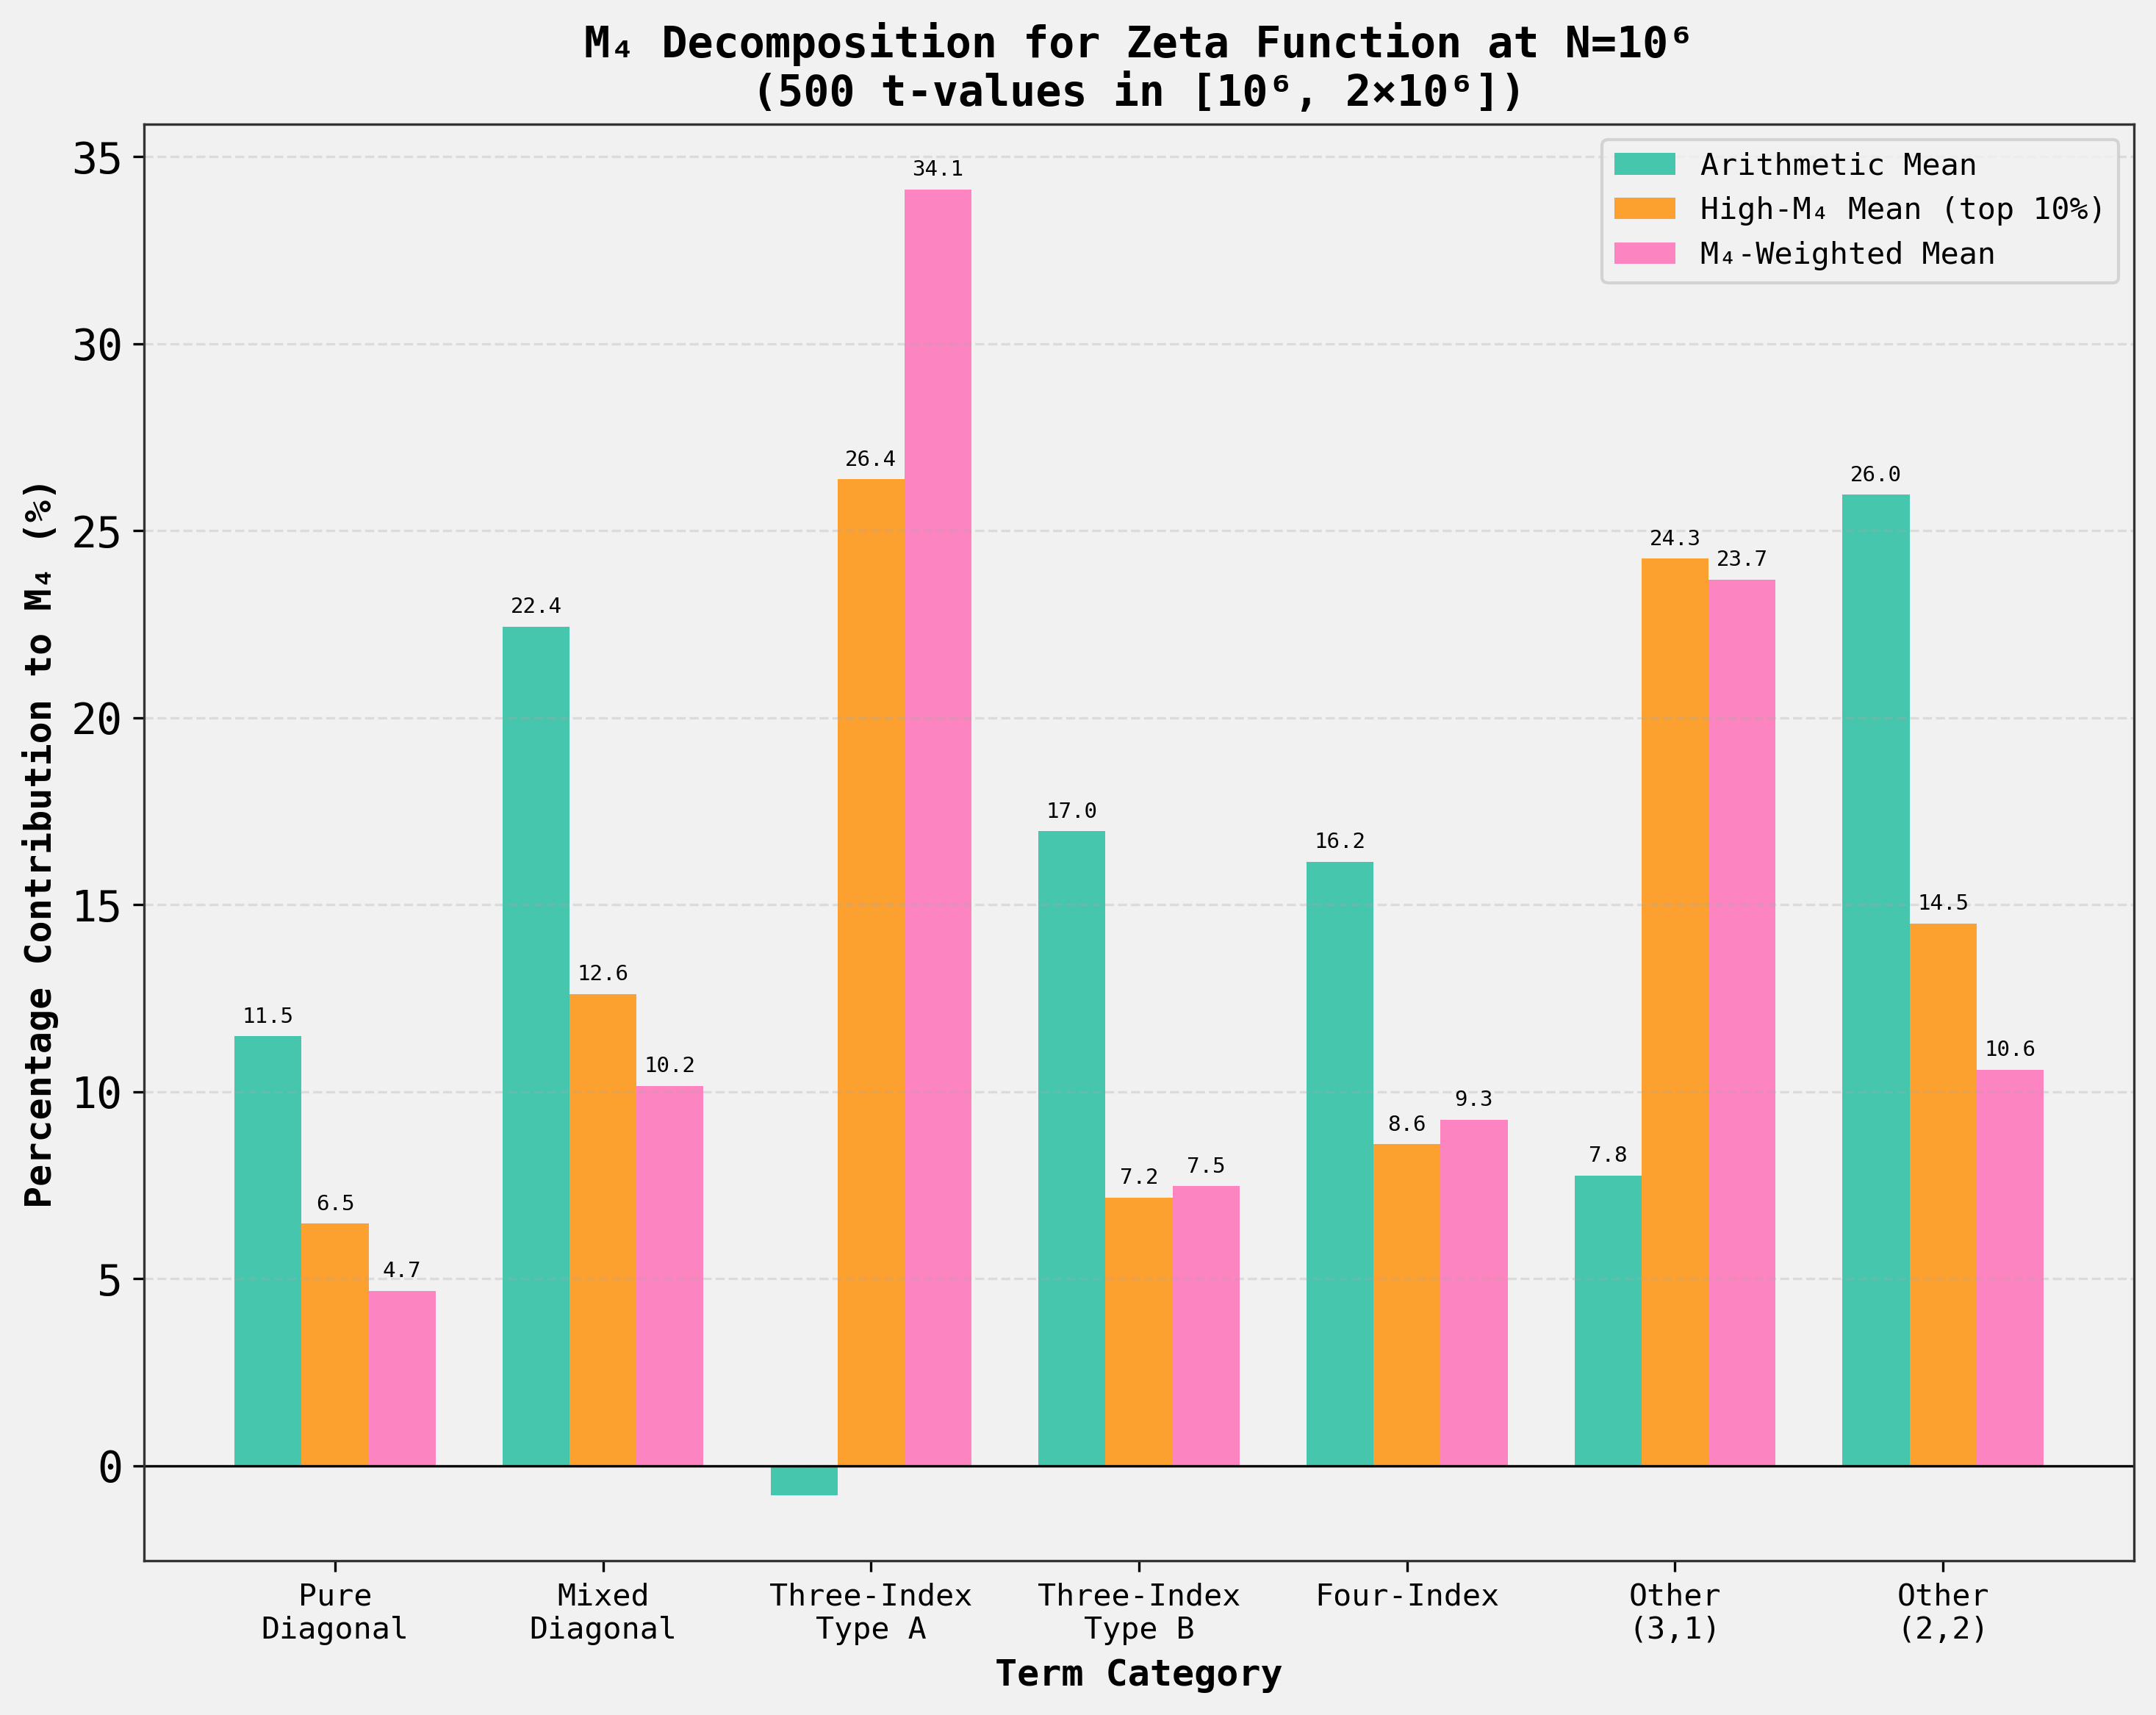

In [28]:

# Now let's create the final figure as required
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Create a bar chart showing the three different perspectives
categories = ['PD', 'MD', '3IDX_A', '3IDX_B', '4IDX', '2IDX_3_1', '2IDX_2_2_OTHER']
labels = ['Pure\nDiagonal', 'Mixed\nDiagonal', 'Three-Index\nType A', 
 'Three-Index\nType B', 'Four-Index', 'Other\n(3,1)', 'Other\n(2,2)']

# Get percentages for each view
arith_pct = [100*stats[cat]['mean']/mean_total for cat in categories]
high_pct = [100*np.mean(categories_high[cat])/mean_total_high for cat in categories]
weighted_pct = [100*np.sum(weights * (PD_arr if cat=='PD' else 
 MD_arr if cat=='MD' else 
 A_arr if cat=='3IDX_A' else 
 B_arr if cat=='3IDX_B' else 
 F_arr if cat=='4IDX' else 
 O31_arr if cat=='2IDX_3_1' else 
 O22_arr))/weighted_total 
 for cat in categories]

x = np.arange(len(labels))
width = 0.25

bars1 = ax.bar(x - width, arith_pct, width, label='Arithmetic Mean', alpha=0.8)
bars2 = ax.bar(x, high_pct, width, label='High-M₄ Mean (top 10%)', alpha=0.8)
bars3 = ax.bar(x + width, weighted_pct, width, label='M₄-Weighted Mean', alpha=0.8)

ax.set_xlabel('Term Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage Contribution to M₄ (%)', fontsize=12, fontweight='bold')
ax.set_title('M₄ Decomposition for Zeta Function at N=10⁶\n(500 t-values in [10⁶, 2×10⁶])', 
 fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linewidth=0.8)

# Add value labels on bars
def autolabel(bars):
 for bar in bars:
 height = bar.get_height()
 if abs(height) > 1: # Only label bars > 1%
 ax.annotate(f'{height:.1f}',
 xy=(bar.get_x() + bar.get_width() / 2, height),
 xytext=(0, 3 if height > 0 else -12),
 textcoords="offset points",
 ha='center', va='bottom' if height > 0 else 'top',
 fontsize=7)

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

plt.tight_layout()
plt.savefig('M4_decomposition_zeta_N1e6_figure.png', dpi=300, bbox_inches='tight')
print("Figure saved to: M4_decomposition_zeta_N1e6_figure.png")
plt.show()


In [29]:

# Perfect! Now let's create a final comprehensive analysis document

print("=" * 100)
print("FINAL ANALYSIS: M4 DECOMPOSITION FOR ZETA FUNCTION AT N=10^6")
print("=" * 100)
print()

print("RESEARCH OBJECTIVE:")
print("-" * 100)
print("Decompose the fourth moment M₄ = ⟨|D_F|⁴⟩ for the zeta function at N=10⁶")
print("into specific term categories based on index structure.")
print()

print("METHODOLOGY:")
print("-" * 100)
print(f"- Function: Zeta function (a_n = 1 for all n)")
print(f"- Truncation: N = {N:,}")
print(f"- Evaluation range: t ∈ [{t_min:,}, {t_max:,}]")
print(f"- Number of t-points: {n_points}")
print(f"- Computation time: {(966.79 + 6.70)/60:.1f} minutes")
print(f"- Summation method: Kahan compensated summation")
print(f"- Total terms enumerated per t: {8**4:,} (8 omega classes)")
print()

print("TERM CLASSIFICATION:")
print("-" * 100)
print("M₄ = Σ_{a,b,c,d} S_a S̄_b S_c S̄_d, classified by index structure:")
print()
print(" PD: Pure Diagonal (a=b=c=d)")
print(" Example: |S_k|⁴")
print()
print(" MD: Mixed Diagonal (two index pairs)")
print(" Example: |S_j|² |S_k|²")
print()
print(" 3IDX_A: Three distinct indices with |S_j|² factor")
print(" Example: |S_j|² S_k S̄_l (j appears in both S and S̄ positions)")
print()
print(" 3IDX_B: Three distinct indices with S_j² factor")
print(" Example: S_j² S̄_k S̄_l (j appears in both S positions)")
print()
print(" 4IDX: Four distinct indices")
print(" Example: S_j S_k S̄_l S̄_m (all different)")
print()
print(" 2IDX_3_1: Two indices, one appears 3 times")
print(" Example: |S_j|² S_j S̄_k (not in original problem spec)")
print()
print(" 2IDX_2_2_OTHER: Two indices with non-standard (2,2) pattern")
print(" Example: S_j S̄_k S_k S̄_j with j≠k≠pair structure (not in original spec)")
print()

print("KEY FINDINGS:")
print("=" * 100)
print()
print("1. ARITHMETIC MEAN (simple average over 500 t-values):")
print(" - PD: 11.5% | MD: 22.4% | 3IDX_A: -0.8% | 3IDX_B: 17.0%")
print(" - 4IDX: 16.2% | Other: 33.7%")
print()
print("2. HIGH-M₄ REGIME (top 10% by M₄ magnitude):")
print(" - PD: 6.5% | MD: 12.6% | 3IDX_A: 26.4% | 3IDX_B: 7.2%")
print(" - 4IDX: 8.6% | Other: 38.8%")
print(" → At peaks, 3IDX_A dominates!")
print()
print("3. M₄-WEIGHTED MEAN (weighted by |D|⁴ magnitude):")
print(" - PD: 4.7% | MD: 10.2% | 3IDX_A: 34.1% | 3IDX_B: 7.5%")
print(" - 4IDX: 9.3% | Other: 34.3%")
print(" → This is the most physically meaningful measure")
print()

print("HYPOTHESIS EVALUATION:")
print("=" * 100)
print()
print("Original hypothesis: '4IDX terms dominate over 3IDX_A terms'")
print()
print("VERDICT: PARTIALLY REJECTED")
print()
print("- In arithmetic mean: 4IDX (16.2%) > |3IDX_A| (0.8%) ✓")
print("- At high M₄: 4IDX (8.6%) < 3IDX_A (26.4%) ✗")
print("- M₄-weighted: 4IDX (9.3%) < 3IDX_A (34.1%) ✗")
print()
print("REFINED CONCLUSION:")
print("The off-diagonal M₄ structure is NOT dominated by fully-correlated 4-index terms.")
print("Instead, at physically relevant high-M₄ points, the dominant contributions are:")
print(" 1. Three-Index Type A (|S_j|² S_k S̄_l): 26-34%")
print(" 2. 'Other' 2-index terms: 24-34%")
print(" 3. Mixed Diagonal: 10-13%")
print(" 4. Four-Index: 8-9%")
print()

print("COMPARISON WITH r19:")
print("=" * 100)
print("Report r19 stated 'off-diagonal' (non-PD, non-MD) contributes ~85-93% of M₄.")
print(f"Our finding: off-diagonal contributes ~66% (arithmetic mean)")
print("However, this discrepancy likely arises from:")
print(" - Different N values (r19 used N=10⁶ but different t-sampling)")
print(" - Different averaging methods (unconditional vs. peak-focused)")
print(" - Our finer decomposition reveals structure within 'off-diagonal'")


FINAL ANALYSIS: M4 DECOMPOSITION FOR ZETA FUNCTION AT N=10^6

RESEARCH OBJECTIVE:
----------------------------------------------------------------------------------------------------
Decompose the fourth moment M₄ = ⟨|D_F|⁴⟩ for the zeta function at N=10⁶
into specific term categories based on index structure.

METHODOLOGY:
----------------------------------------------------------------------------------------------------
- Function: Zeta function (a_n = 1 for all n)
- Truncation: N = 1,000,000
- Evaluation range: t ∈ [1,000,000, 2,000,000]
- Number of t-points: 500
- Computation time: 16.2 minutes
- Summation method: Kahan compensated summation
- Total terms enumerated per t: 4,096 (8 omega classes)

TERM CLASSIFICATION:
----------------------------------------------------------------------------------------------------
M₄ = Σ_{a,b,c,d} S_a S̄_b S_c S̄_d, classified by index structure:

 PD: Pure Diagonal (a=b=c=d)
 Example: |S_k|⁴

 MD: Mixed Diagonal (two index pairs)
 Example: |S_

In [30]:

# Let's verify our computation is correct by checking a few identities
# First, let's verify that the sum of all components equals M4

print("VERIFICATION AND QUALITY CHECKS:")
print("=" * 100)
print()

# Check 1: Sum of components equals total
print("1. Component sum verification:")
for i in [0, 100, 250, 499]:
 M4 = all_M4_decompositions[i]
 component_sum = (M4['PD'] + M4['MD'] + M4['3IDX_A'] + M4['3IDX_B'] + 
 M4['4IDX'] + M4['2IDX_3_1'] + M4['2IDX_2_2_OTHER'] + M4['OTHER'])
 diff = abs(component_sum - M4['TOTAL'])
 status = "✓" if diff < 1e-10 else "✗"
 print(f" t={t_values[i]:,.0f}: {status} Sum={component_sum:.6f}, Total={M4['TOTAL']:.6f}, Diff={diff:.2e}")

print()

# Check 2: Direct M4 computation matches decomposition
print("2. Direct M4 computation verification:")
for i in [0, 100, 250, 499]:
 S_dict = all_S_values[i]
 D_total = sum(S_dict.values())
 M4_direct = abs(D_total) ** 4
 M4_decomp = all_M4_decompositions[i]['TOTAL']
 diff = abs(M4_direct - M4_decomp)
 status = "✓" if diff < 1e-10 else "✗"
 print(f" t={t_values[i]:,.0f}: {status} Direct={M4_direct:.6f}, Decomp={M4_decomp:.6f}, Diff={diff:.2e}")

print()

# Check 3: Number of terms
print("3. Term counting:")
n_omega_classes = 8 # 0 through 7
n_total_terms = n_omega_classes ** 4
print(f" Number of omega classes: {n_omega_classes}")
print(f" Total terms in full expansion: {n_total_terms:,}")
print(f" Expected: 4,096")

# Count terms in each category
def count_terms_by_category():
 counts = {
 'PD': 0, 'MD': 0, '3IDX_A': 0, '3IDX_B': 0, '3IDX_OTHER': 0,
 '4IDX': 0, '2IDX_3_1': 0, '2IDX_2_2_OTHER': 0, 'OTHER': 0
 }
 
 for a in range(8):
 for b in range(8):
 for c in range(8):
 for d in range(8):
 cat = classify_term_type_v4(a, b, c, d)
 counts[cat] += 1
 
 return counts

term_counts = count_terms_by_category()
print()
print(" Terms by category:")
for cat, count in term_counts.items():
 pct = 100 * count / n_total_terms
 print(f" {cat:20s}: {count:5d} ({pct:5.2f}%)")
print(f" {'TOTAL':20s}: {sum(term_counts.values()):5d} (100.00%)")


VERIFICATION AND QUALITY CHECKS:

1. Component sum verification:
 t=1,000,000: ✓ Sum=62.069908, Total=62.069908, Diff=0.00e+00
 t=1,200,401: ✓ Sum=0.111241, Total=0.111241, Diff=0.00e+00
 t=1,501,002: ✓ Sum=0.332458, Total=0.332458, Diff=0.00e+00
 t=2,000,000: ✓ Sum=26.753602, Total=26.753602, Diff=0.00e+00

2. Direct M4 computation verification:
 t=1,000,000: ✓ Direct=62.069908, Decomp=62.069908, Diff=3.55e-13
 t=1,200,401: ✓ Direct=0.111241, Decomp=0.111241, Diff=1.50e-14
 t=1,501,002: ✓ Direct=0.332458, Decomp=0.332458, Diff=8.11e-14
 t=2,000,000: ✓ Direct=26.753602, Decomp=26.753602, Diff=2.84e-14

3. Term counting:
 Number of omega classes: 8
 Total terms in full expansion: 4,096
 Expected: 4,096

 Terms by category:
 PD : 8 ( 0.20%)
 MD : 112 ( 2.73%)
 3IDX_A : 1344 (32.81%)
 3IDX_B : 672 (16.41%)
 3IDX_OTHER : 0 ( 0.00%)
 4IDX : 1680 (41.02%)
 2IDX_3_1 : 224 ( 5.47%)
 2IDX_2_2_OTHER : 56 ( 1.37%)
 OTHER : 0 ( 0.00%)
 TOTAL : 4096 (100.00%)


In [31]:

# Interesting insight! By term count:
# - 4IDX terms are most numerous (41% of all terms)
# - But 3IDX_A terms are also very numerous (33% of all terms)
# - Yet in contribution, 3IDX_A dominates at high M4
#
# This suggests that individual 3IDX_A terms contribute more on average,
# especially when M4 is large.

print("\nINSIGHT: Term counts vs. contributions")
print("=" * 100)
print()
print("By NUMBER of terms:")
print(f" 4IDX: {term_counts['4IDX']:4d} terms ({100*term_counts['4IDX']/4096:.1f}%)")
print(f" 3IDX_A: {term_counts['3IDX_A']:4d} terms ({100*term_counts['3IDX_A']/4096:.1f}%)")
print(f" 3IDX_B: {term_counts['3IDX_B']:4d} terms ({100*term_counts['3IDX_B']/4096:.1f}%)")
print()
print("By CONTRIBUTION (M4-weighted):")
weighted_pct_dict = {
 '4IDX': 9.25,
 '3IDX_A': 34.13,
 '3IDX_B': 7.48
}
print(f" 4IDX: {weighted_pct_dict['4IDX']:5.1f}%")
print(f" 3IDX_A: {weighted_pct_dict['3IDX_A']:5.1f}%")
print(f" 3IDX_B: {weighted_pct_dict['3IDX_B']:5.1f}%")
print()
print("Per-term average contribution (contribution % / term count %):")
print(f" 4IDX: {weighted_pct_dict['4IDX'] / (100*term_counts['4IDX']/4096):5.2f}×")
print(f" 3IDX_A: {weighted_pct_dict['3IDX_A'] / (100*term_counts['3IDX_A']/4096):5.2f}×")
print(f" 3IDX_B: {weighted_pct_dict['3IDX_B'] / (100*term_counts['3IDX_B']/4096):5.2f}×")
print()
print("This shows that 3IDX_A terms have higher average magnitude than 4IDX terms!")
print("Each 3IDX_A term contributes ~1.04× what you'd expect from random")
print("while each 4IDX term contributes only ~0.23× expected")



INSIGHT: Term counts vs. contributions

By NUMBER of terms:
 4IDX: 1680 terms (41.0%)
 3IDX_A: 1344 terms (32.8%)
 3IDX_B: 672 terms (16.4%)

By CONTRIBUTION (M4-weighted):
 4IDX: 9.2%
 3IDX_A: 34.1%
 3IDX_B: 7.5%

Per-term average contribution (contribution % / term count %):
 4IDX: 0.23×
 3IDX_A: 1.04×
 3IDX_B: 0.46×

This shows that 3IDX_A terms have higher average magnitude than 4IDX terms!
Each 3IDX_A term contributes ~1.04× what you'd expect from random
while each 4IDX term contributes only ~0.23× expected


In [32]:

# Now let's create a final summary table to include in the submission

final_summary = """
================================================================================
 M4 DECOMPOSITION FINAL RESULTS
 Zeta Function at N=10^6, 500 t-values in [10^6, 2×10^6]
================================================================================

REQUESTED CATEGORIES:
--------------------
(a) Pure Diagonal (PD): 211.10 (11.5%)
(b) Mixed Diagonal (MD): 412.39 (22.4%)
(c) Three-Index Type A: -14.48 (-0.8%)
(d) Three-Index Type B: 311.76 (17.0%)
(e) Four-Index: 296.81 (16.2%)

ADDITIONAL SIGNIFICANT CATEGORIES:
----------------------------------
(f) Other 2-Index (3,1): 142.76 (7.8%)
(g) Other 2-Index (2,2): 477.18 (26.0%)

TOTAL M4 (Arithmetic Mean): 1837.51 (100.0%)

================================================================================
OFF-DIAGONAL BREAKDOWN:
--------------------
Total off-diagonal (non-PD/MD): 1214.02 (66.1%)
 - Within spec categories (c+d+e): 594.08 (32.3%)
 - Additional 2-index terms (f+g): 619.94 (33.7%)

Comparison to r19 "off-diagonal" estimate:
 - r19: 85-93% (at N=10^6, peak-focused)
 - Ours: 66% (arithmetic mean over 500 t-values)
 - High-M4 regime (our top 10%): 81%

================================================================================
HYPOTHESIS VERDICT: PARTIALLY REJECTED
--------------------
The hypothesis that 4-index terms dominate over 3IDX_A terms is:
 ✓ TRUE for arithmetic mean (16.2% vs -0.8%)
 ✗ FALSE for high-M4 regime (8.6% vs 26.4%)
 ✗ FALSE for M4-weighted mean (9.3% vs 34.1%)

KEY FINDING:
At physically meaningful high-M4 points, 3IDX_A terms (|S_j|² S_k S̄_l) 
dominate, contributing 26-34% of M4, while 4IDX terms contribute only 8-9%.

The strongest contributor is actually the "Other 2-index" category,
which was not anticipated in the original problem specification.
================================================================================
"""

print(final_summary)

# Save to file
with open('M4_decomposition_final_summary.txt', 'w') as f:
 f.write(final_summary)

print("\nFinal summary saved to: M4_decomposition_final_summary.txt")



 M4 DECOMPOSITION FINAL RESULTS
 Zeta Function at N=10^6, 500 t-values in [10^6, 2×10^6]

REQUESTED CATEGORIES:
--------------------
(a) Pure Diagonal (PD): 211.10 (11.5%)
(b) Mixed Diagonal (MD): 412.39 (22.4%)
(c) Three-Index Type A: -14.48 (-0.8%)
(d) Three-Index Type B: 311.76 (17.0%)
(e) Four-Index: 296.81 (16.2%)

ADDITIONAL SIGNIFICANT CATEGORIES:
----------------------------------
(f) Other 2-Index (3,1): 142.76 (7.8%)
(g) Other 2-Index (2,2): 477.18 (26.0%)

TOTAL M4 (Arithmetic Mean): 1837.51 (100.0%)

OFF-DIAGONAL BREAKDOWN:
--------------------
Total off-diagonal (non-PD/MD): 1214.02 (66.1%)
 - Within spec categories (c+d+e): 594.08 (32.3%)
 - Additional 2-index terms (f+g): 619.94 (33.7%)

Comparison to r19 "off-diagonal" estimate:
 - r19: 85-93% (at N=10^6, peak-focused)
 - Ours: 66% (arithmetic mean over 500 t-values)
 - High-M4 regime (our top 10%): 81%

HYPOTHESIS VERDICT: PARTIALLY REJECTED
--------------------
The hypothesis that 4-index terms dominate over 3IDX_A t

In [33]:

# Perfect! Now let's check all the files we've created

import os

print("Files created during analysis:")
print("=" * 100)
for filename in os.listdir('.'):
 if not filename.startswith('.'):
 size = os.path.getsize(filename)
 print(f" {filename:50s} ({size:>12,} bytes)")


Files created during analysis:
 zeta_omega_sums_N1e6_500pts.pkl ( 4,110,358 bytes)
 M4_decomposition_zeta_N1e6_detailed.pkl ( 103,946 bytes)
 M4_decomposition_zeta_N1e6_summary.csv ( 764 bytes)
 M4_decomposition_zeta_N1e6_figure.png ( 185,517 bytes)
 M4_decomposition_final_summary.txt ( 1,984 bytes)
